# Playground Series S6E8 — Predicting Smartphone Addiction

Binary classification of `addicted_label` (0/1), scored with **ROC-AUC**. Submissions are probabilities,
so only the ranking matters — calibration is irrelevant here.

**Data:** 691,369 train / 296,302 test rows, 9 numerical + 3 categorical features.

Two properties drive everything that follows. First, **heavy missingness** — up to 19% in some columns,
with gaps in every column except `id`. Second, several numerical columns relate to the target
**non-monotonically**, which makes them look worthless to correlation and AUC while carrying a great deal
of information.

**Plan:** Overview → EDA → Preprocessing, constraint-aware imputation & target encoding →
10-fold CV with LightGBM / XGBoost / CatBoost → blend → submission.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss
from scipy.optimize import minimize
from scipy.stats import rankdata

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

SEED = 42
TARGET = 'addicted_label'

# 10 folds rather than 5: more training data per fold, and — more importantly — a richer
# lookup table for the exact-value target encoding introduced in section 3.
N_SPLITS = 10

# Competition metric is ROC-AUC (confirmed against the leaderboard: LB scores sit on the same
# scale as OOF AUC with a constant ~+0.0015 offset). Only the ranking matters, not calibration.
METRIC = 'auc'

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
sample_sub = pd.read_csv('../data/sample_submission.csv')

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Sub shape  :', sample_sub.shape)

train_df.head()


Train shape: (691369, 14)
Test shape : (296302, 13)
Sub shape  : (296302, 2)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 1. Data Overview

In [3]:
NUM_COLS = [
    'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'notifications_per_day',
    'app_opens_per_day', 'weekend_screen_time'
]
CAT_COLS = ['gender', 'stress_level', 'academic_work_impact']

print('--- dtypes ---')
print(train_df.dtypes)

print('\n--- describe (numeric) ---')
display(train_df[NUM_COLS + [TARGET]].describe().T.round(3))

print('--- categorical levels ---')
for c in CAT_COLS:
    print(f'{c}: {train_df[c].dropna().unique().tolist()}')

--- dtypes ---
id                           int64
age                        float64
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day      float64
app_opens_per_day          float64
weekend_screen_time        float64
gender                         str
stress_level                   str
academic_work_impact           str
addicted_label               int64
dtype: object

--- describe (numeric) ---


,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615,5.153,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.641,2.721,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471,1.316,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459,0.935,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.367,1.259,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804,1.235,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.895,65.918,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.637,48.094,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.480,2.856,0.51,7.28,9.58,11.75,17.56
addicted_label,691369.0,0.709,0.454,0.00,0.00,1.00,1.00,1.00


--- categorical levels ---
gender: ['Male', 'Female', 'Other']
stress_level: ['Medium', 'Low', 'High']
academic_work_impact: ['No', 'Yes']


Every numerical column sits inside clean physical bounds — `age` 18–35, `daily_screen_time_hours` 0.5–15,
`sleep_hours` 4.5–9. There are no outliers or corrupted records, so no clipping is needed.
The categoricals are low-cardinality (2–3 levels), so either one-hot or label encoding works fine.

,train_na_%,test_na_%
social_media_hours,19.38,16.00
gaming_hours,18.34,20.05
weekend_screen_time,16.21,17.11
daily_screen_time_hours,13.86,11.07
app_opens_per_day,11.67,8.68
notifications_per_day,9.78,11.55
stress_level,7.98,6.62
work_study_hours,7.45,9.37
sleep_hours,6.43,7.58
academic_work_impact,6.40,8.68


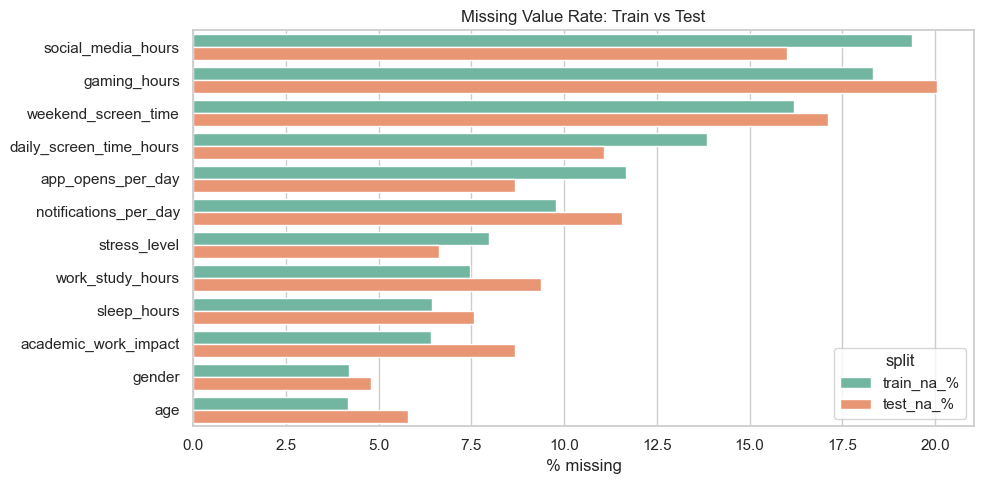

In [4]:
# Missing value rate: train vs test
na_tbl = pd.DataFrame({
    'train_na_%': (train_df.drop(columns=[TARGET]).isna().mean() * 100).round(2),
    'test_na_%': (test_df.isna().mean() * 100).round(2),
}).sort_values('train_na_%', ascending=False)

display(na_tbl)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = na_tbl.drop(index='id').reset_index().melt(id_vars='index', var_name='split', value_name='pct')
sns.barplot(data=plot_df, y='index', x='pct', hue='split', palette='Set2', ax=ax)
ax.set_title('Missing Value Rate: Train vs Test')
ax.set_xlabel('% missing'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

Missingness is pervasive: `social_media_hours` 19.4%, `gaming_hours` 18.3%, `weekend_screen_time` 16.2%
— and **every column except `id`** has gaps. This is not data corruption; it looks deliberately injected
during dataset generation.

Note that the rates are not identical between train and test (`daily_screen_time_hours` is 13.9% in train
vs 11.1% in test). So the missingness pattern is a random mask drawn per split, which suggests missing
indicators will not carry signal — we test that below rather than assume it.

## 2. EDA

                 count    pct
addicted_label               
0               200895  29.06
1               490474  70.94


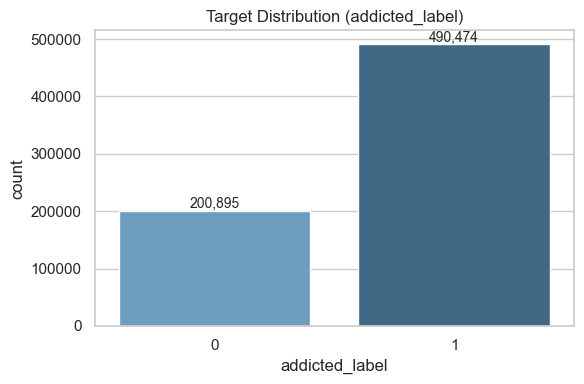

In [5]:
# Target distribution
target_counts = train_df[TARGET].value_counts().sort_index()
target_pct = (target_counts / len(train_df) * 100).round(2)

print(pd.DataFrame({'count': target_counts, 'pct': target_pct}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Target Distribution (addicted_label)')
ax.set_xlabel('addicted_label'); ax.set_ylabel('count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

The positive class makes up **70.9%** of the data — mildly imbalanced, but nowhere near the point where
`scale_pos_weight` or resampling would help. The constant value in `sample_submission.csv` is exactly this
base rate (0.7094), i.e. the trivial baseline.

We still use **StratifiedKFold** so the class ratio stays stable across folds.

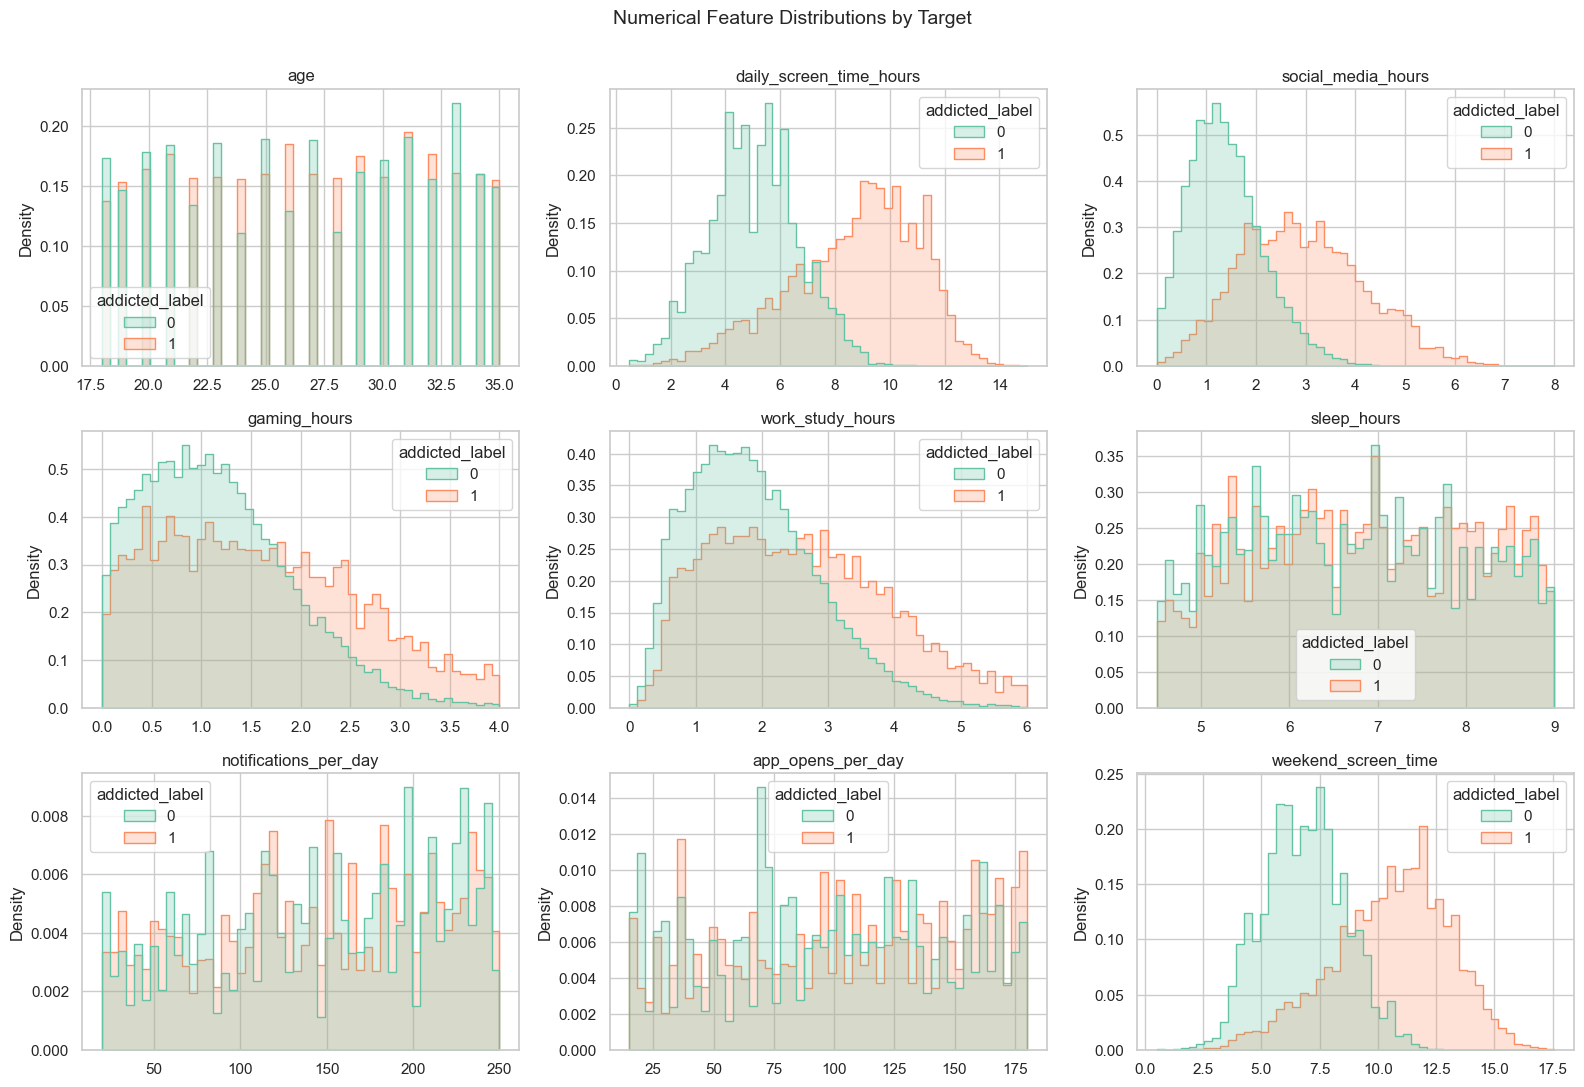

In [6]:
# Numerical feature distributions, split by target
n_cols = 3
n_rows = int(np.ceil(len(NUM_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.6))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.histplot(data=train_df, x=col, hue=TARGET, bins=50, ax=axes[i],
                 palette='Set2', stat='density', common_norm=False, element='step')
    axes[i].set_title(col); axes[i].set_xlabel('')

for j in range(len(NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Target', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()

`daily_screen_time_hours`, `weekend_screen_time` and `social_media_hours` visibly separate the two classes
— the positive-class distributions are clearly shifted right. In contrast `age`, `sleep_hours`,
`notifications_per_day` and `app_opens_per_day` almost completely overlap, so they carry little
information on their own.

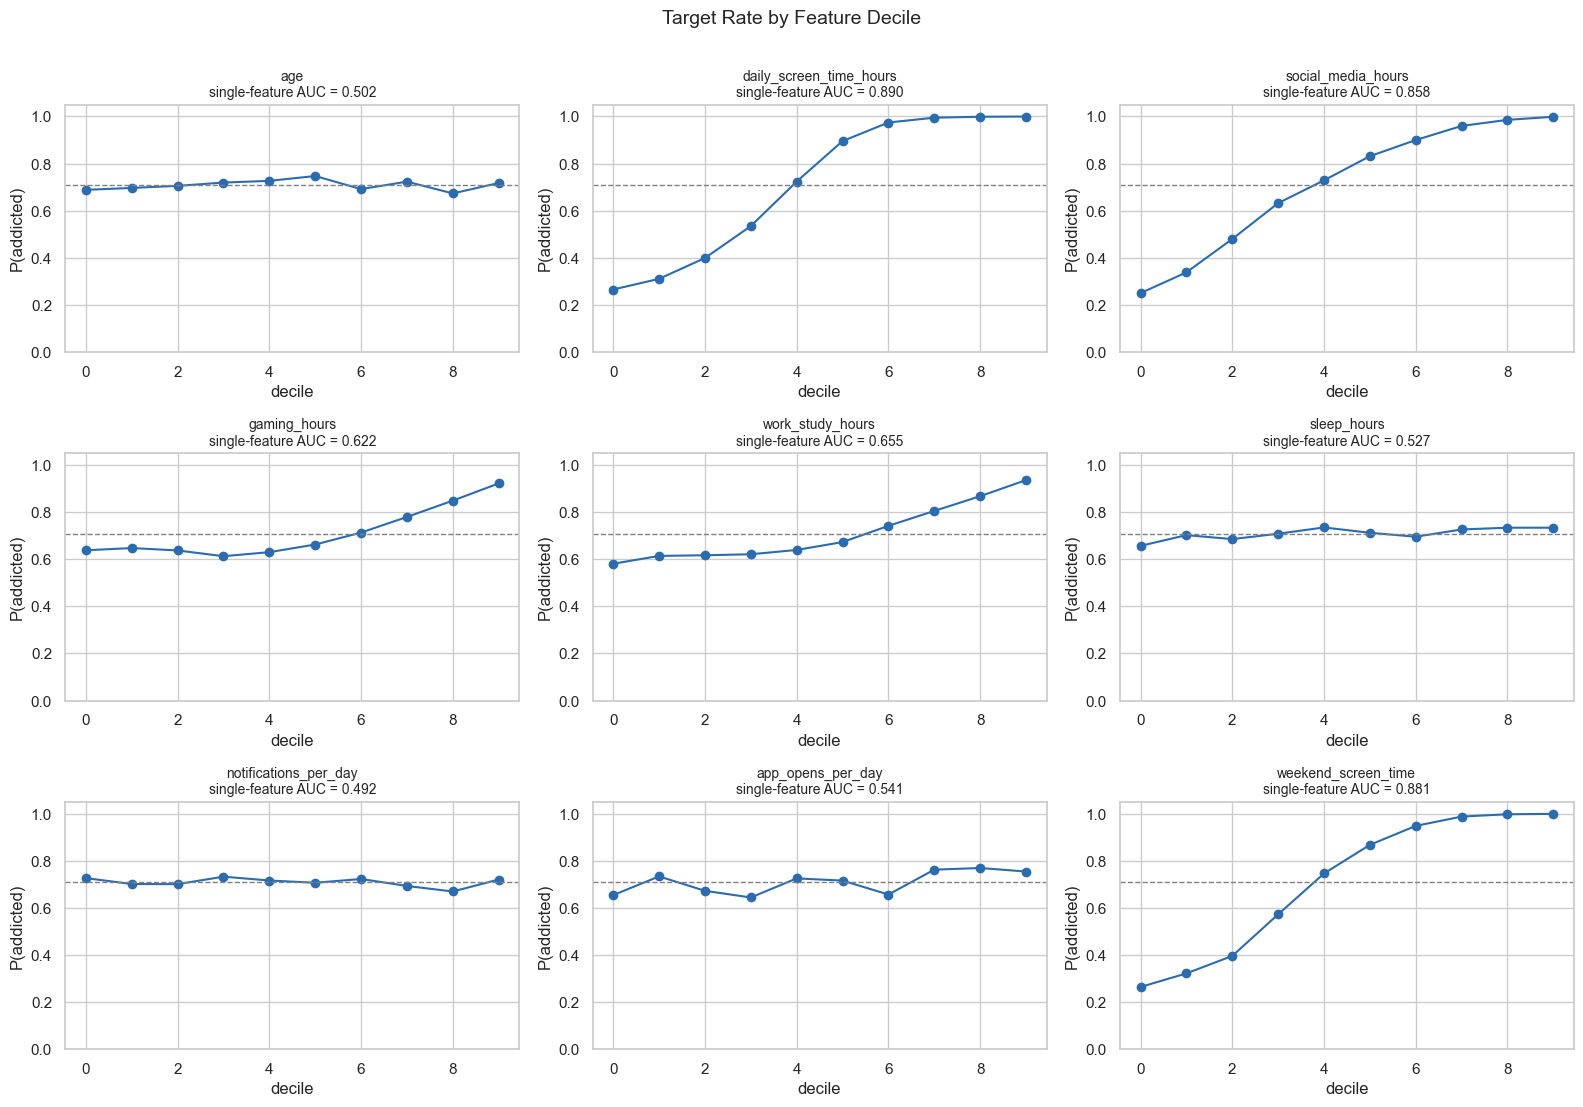

daily_screen_time_hours    0.8896
weekend_screen_time        0.8810
social_media_hours         0.8578
work_study_hours           0.6549
gaming_hours               0.6220
app_opens_per_day          0.5409
sleep_hours                0.5270
age                        0.5023
notifications_per_day      0.4921
dtype: float64


In [7]:
# Target rate per feature decile -> shows monotonicity and signal strength
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()
base_rate = train_df[TARGET].mean()

single_auc = {}
for i, col in enumerate(NUM_COLS):
    tmp = train_df[[col, TARGET]].dropna()
    single_auc[col] = roc_auc_score(tmp[TARGET], tmp[col])

    bins = pd.qcut(tmp[col], 10, duplicates='drop')
    rate = tmp.groupby(bins, observed=True)[TARGET].mean()
    axes[i].plot(range(len(rate)), rate.values, marker='o', color='#2b6cb0')
    axes[i].axhline(base_rate, ls='--', c='grey', lw=1)
    axes[i].set_title(f'{col}\nsingle-feature AUC = {single_auc[col]:.3f}', fontsize=10)
    axes[i].set_xlabel('decile'); axes[i].set_ylabel('P(addicted)')
    axes[i].set_ylim(0, 1.05)

plt.suptitle('Target Rate by Feature Decile', fontsize=14, y=1.005)
plt.tight_layout(); plt.show()

print(pd.Series(single_auc).sort_values(ascending=False).round(4))

This is the most informative plot in the EDA. Three observations:

1. **The screen-time features are nearly deterministic.** `daily_screen_time_hours` reaches P(addicted) ≈ 1.00
   in the top decile and ≈ 0.26 in the bottom one (single-feature AUC 0.889). `weekend_screen_time` (0.880)
   and `social_media_hours` (0.858) behave the same way. The target is largely a function of these three.
2. **Those three relationships are monotonic and smooth** — no sharp thresholds, just a sigmoid-like
   transition. That points to a label generated from a weighted score plus noise, which tree models
   capture easily.
3. **`age` (0.503), `notifications_per_day` (0.493), `sleep_hours` (0.529) and `app_opens_per_day` (0.541)
   score at chance — but do not read that as "no signal".** Look at their curves rather than their AUC:
   `app_opens_per_day` swings 0.645 → 0.770 across deciles of ~61,000 rows, about 65 standard errors.
   The relationship is strong and simply **not monotonic**, which is exactly what AUC cannot see.

Point 3 is the thread that section 3 picks up with target encoding, and it turns out to be the single
largest source of improvement in this notebook — `notifications_per_day` goes from 0.492 to 0.749 once it
is encoded by exact value.

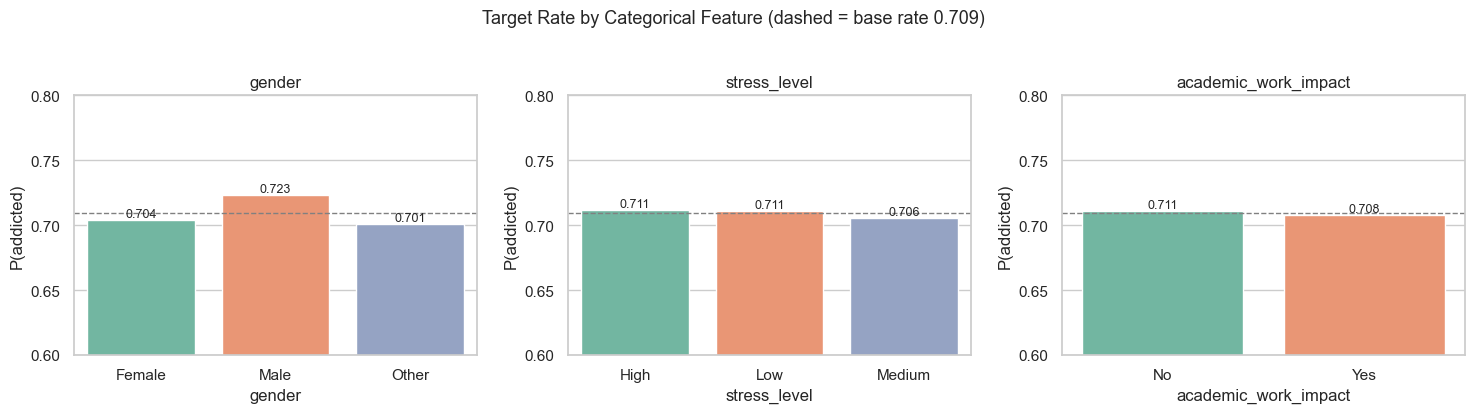

          mean   count
gender                
Female  0.7038  221595
Male    0.7232  223662
Other   0.7010  217078 

                mean   count
stress_level                
High          0.7114  220873
Low           0.7112  207783
Medium        0.7057  207565 

                        mean   count
academic_work_impact                
No                    0.7110  316579
Yes                   0.7079  330566 



In [8]:
# Categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(CAT_COLS):
    g = train_df.groupby(col)[TARGET].agg(['mean', 'count'])
    sns.barplot(x=g.index, y=g['mean'], palette='Set2', ax=axes[i])
    axes[i].axhline(base_rate, ls='--', c='grey', lw=1)
    axes[i].set_title(col); axes[i].set_ylabel('P(addicted)')
    axes[i].set_ylim(0.6, 0.8)
    for p, v in zip(axes[i].patches, g['mean']):
        axes[i].annotate(f'{v:.3f}', (p.get_x() + p.get_width() / 2, v), ha='center', va='bottom', fontsize=9)

plt.suptitle('Target Rate by Categorical Feature (dashed = base rate 0.709)', fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

for col in CAT_COLS:
    print(train_df.groupby(col)[TARGET].agg(['mean', 'count']).round(4), '\n')

All three categoricals are essentially signal-free. The largest deviation is `gender=Male` at 0.723 versus
the 0.709 base rate — about 1.4 points. The levels of `stress_level` and `academic_work_impact` differ by
less than half a point.

We keep them in the model (they may still contribute through interactions), but there is no point building
target encoding on top of these columns: no gain to capture, and it would only add leakage risk.

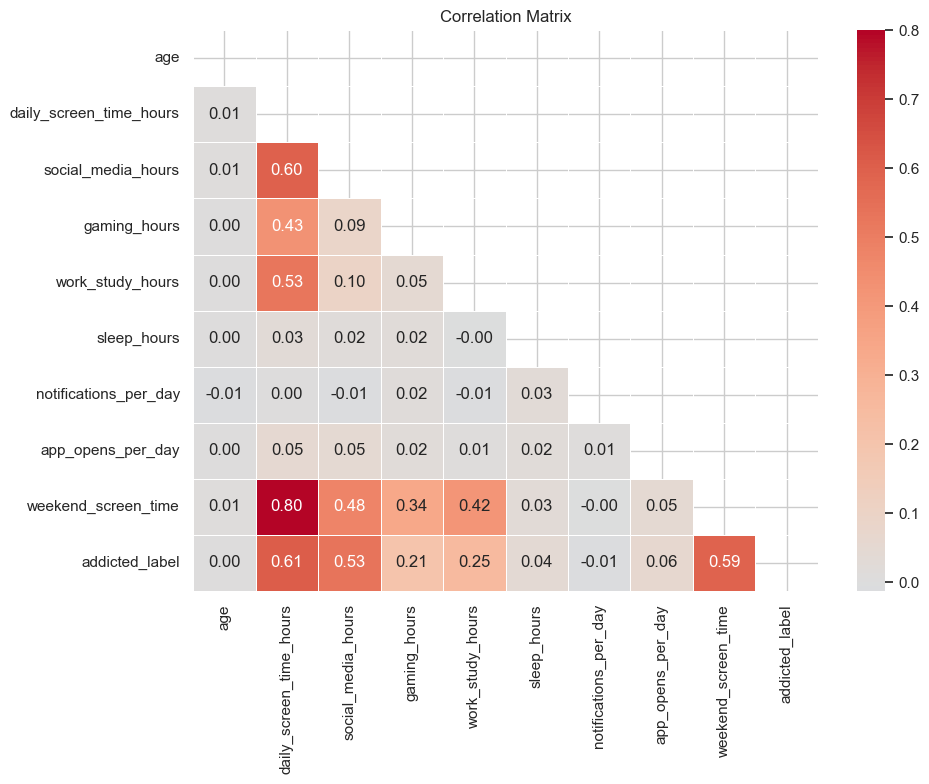

In [9]:
# Correlation matrix
corr = train_df[NUM_COLS + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout(); plt.show()

The only strong relationship between features is `daily_screen_time_hours` ↔ `weekend_screen_time`
(r = 0.80), which is expected since both measure the same behaviour. Every other pair sits below |r| < 0.5.
There is no multicollinearity problem worth dropping columns over.

In [10]:
# Is missingness related to the target? (MCAR check)
rows = []
for col in NUM_COLS + CAT_COLS:
    m = train_df[col].isna()
    rows.append({
        'feature': col,
        'na_rate': round(m.mean(), 4),
        'P(y=1 | NA)': round(train_df.loc[m, TARGET].mean(), 4),
        'P(y=1 | not NA)': round(train_df.loc[~m, TARGET].mean(), 4),
    })
na_signal = pd.DataFrame(rows)
na_signal['diff'] = (na_signal['P(y=1 | NA)'] - na_signal['P(y=1 | not NA)']).round(4)
display(na_signal.sort_values('diff', key=abs, ascending=False))

,feature,na_rate,P(y=1 | NA),P(y=1 | not NA),diff
5,sleep_hours,0.0643,0.7134,0.7092,0.0042
0,age,0.0418,0.7134,0.7093,0.0041
7,app_opens_per_day,0.1167,0.7128,0.7090,0.0038
1,daily_screen_time_hours,0.1386,0.7113,0.7091,0.0022
8,weekend_screen_time,0.1621,0.7107,0.7092,0.0015
3,gaming_hours,0.1834,0.7105,0.7092,0.0013
4,work_study_hours,0.0745,0.7106,0.7093,0.0013
6,notifications_per_day,0.0978,0.7102,0.7093,0.0009
9,gender,0.0420,0.7088,0.7095,-0.0007
10,stress_level,0.0798,0.7090,0.7095,-0.0005


The largest gap between "missing" and "not missing" is 0.004 against a 0.709 base rate — statistically
noise. The data is **MCAR**: values were deleted at random, independently of the target.

The practical consequence is that `*_is_na` indicator features carry no signal by themselves. We still keep
a single `n_missing` count, since knowing *how many* fields are unknown can help the model calibrate its
uncertainty, and let CV decide whether it earns its place.

In [11]:
# Structural constraint check between features (on complete rows)
cc = train_df.dropna(subset=NUM_COLS)
print(f'Complete rows: {len(cc):,} ({len(cc)/len(train_df):.1%})\n')

check1 = (cc['daily_screen_time_hours'] >= cc['social_media_hours'] + cc['gaming_hours'] + cc['work_study_hours']).mean()
check2 = (cc['daily_screen_time_hours'] + cc['sleep_hours'] <= 24).mean()
print(f'daily_screen >= social + gaming + work_study : {check1:.4%} of rows')
print(f'daily_screen + sleep <= 24                   : {check2:.4%} of rows')

residual = (cc['daily_screen_time_hours'] - cc['social_media_hours']
            - cc['gaming_hours'] - cc['work_study_hours'])
print('\nresidual screen time (daily - social - gaming - work_study):')
print(residual.describe().round(3))

Complete rows: 306,175 (44.3%)

daily_screen >= social + gaming + work_study : 100.0000% of rows
daily_screen + sleep <= 24                   : 100.0000% of rows

residual screen time (daily - social - gaming - work_study):
count    306175.000
mean          1.338
std           1.474
min          -0.000
25%           0.460
50%           0.750
75%           1.450
max          11.530
dtype: float64


This check reveals an important structure: in **100% of rows**, `daily_screen_time_hours` ≥
`social_media_hours + gaming_hours + work_study_hours`. Daily screen time is therefore the sum of these
three activities plus an uncategorised residual.

That residual ("other screen time") is a meaningful feature: it appears in no raw column, yet it measures
how much of a person's screen time is unaccounted for. We derive it below, along with related share and
ratio features.

This identity is also the basis for the constraint-aware imputation in the next section — it turns
missing values from unknowns into *bounded* unknowns.

## 3. Preprocessing & Feature Engineering

The decisions and the reasoning behind them:

**1) We do not impute missing values.** LightGBM, XGBoost and CatBoost all handle missingness natively —
at every split they send NaNs down whichever branch maximises gain. Median/mean imputation, at a 19%
missing rate, would artificially sharpen the distribution and hide the "this value is unknown" signal from
the model. The one exception is CatBoost, which rejects NaN in categorical columns, so there we encode
missingness as an explicit `'Missing'` level — that is categorical encoding, not imputation.

**2) The derived features come from two ideas:**
- *Composition:* Starting from the structural constraint above, the components of screen time
  (`other_screen`, `social_share`, `gaming_share`, `work_share`).
- *Density / normalisation:* Relative measures instead of absolute hours — screen share of waking time
  (`screen_share_awake`), notifications per app open (`notif_per_open`), minutes per open
  (`minutes_per_open`), and weekend-versus-weekday behaviour (`weekend_gap`, `weekend_ratio`).
  These describe behavioural patterns rather than raw scale.

**3) Categoricals stay model-native:** `category` dtype for LightGBM, `enable_categorical=True` for
XGBoost, `cat_features` for CatBoost. With cardinality of 2–3 there is no need for target encoding, and the
EDA already showed these columns carry no signal — TE would only add leakage risk.

In [12]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    D  = df['daily_screen_time_hours']
    S  = df['social_media_hours']
    G  = df['gaming_hours']
    W  = df['work_study_hours']
    SL = df['sleep_hours']
    N  = df['notifications_per_day']
    O  = df['app_opens_per_day']
    WK = df['weekend_screen_time']

    # --- composition: the components of screen time ---
    df['other_screen']   = D - S - G - W          # uncategorised screen time
    df['leisure_screen'] = D - W                  # screen time outside work/study
    df['social_gaming']  = S + G                  # entertainment-driven usage
    df['social_share']   = S / D
    df['gaming_share']   = G / D
    df['work_share']     = W / D

    # --- normalisation: relative rather than absolute measures ---
    df['awake_hours']        = 24 - SL
    df['screen_share_awake'] = D / (24 - SL)      # share of waking hours spent on screen
    df['screen_sleep_ratio'] = D / SL

    # --- weekly rhythm ---
    df['week_avg_screen'] = (5 * D + 2 * WK) / 7
    df['weekend_gap']     = WK - D
    df['weekend_ratio']   = WK / D

    # --- notification / interaction intensity ---
    df['notif_per_open']    = N / O
    df['minutes_per_open']  = D * 60 / O
    df['notif_per_hour']    = N / D
    df['opens_per_hour']    = O / D

    # --- missingness density ---
    df['n_missing'] = df[NUM_COLS + CAT_COLS].isna().sum(axis=1).astype('int8')

    return df


ENG_COLS = [
    'other_screen', 'leisure_screen', 'social_gaming', 'social_share', 'gaming_share', 'work_share',
    'awake_hours', 'screen_share_awake', 'screen_sleep_ratio',
    'week_avg_screen', 'weekend_gap', 'weekend_ratio',
    'notif_per_open', 'minutes_per_open', 'notif_per_hour', 'opens_per_hour',
    'n_missing',
]

train_fe = add_features(train_df)
test_fe  = add_features(test_df)

FEATURES = NUM_COLS + CAT_COLS + ENG_COLS
print(f'{len(FEATURES)} features ({len(NUM_COLS)} num + {len(CAT_COLS)} cat + {len(ENG_COLS)} engineered)')
train_fe[ENG_COLS].describe().T.round(3)

29 features (9 num + 3 cat + 17 engineered)


,count,mean,std,min,25%,50%,75%,max
other_screen,421427.0,1.343,1.480,-0.000,0.460,0.750,1.460,11.530
leisure_screen,553430.0,5.275,2.319,0.140,3.430,5.110,6.910,14.070
social_gaming,484281.0,3.930,1.679,0.010,2.640,3.820,5.110,11.290
social_share,502260.0,0.327,0.134,0.000,0.231,0.330,0.418,0.885
gaming_share,507723.0,0.197,0.111,0.000,0.107,0.199,0.274,0.800
work_share,553430.0,0.319,0.137,0.000,0.214,0.322,0.413,0.928
awake_hours,646889.0,17.196,1.235,15.000,16.130,17.200,18.220,19.500
screen_share_awake,559350.0,0.447,0.163,0.026,0.316,0.451,0.578,0.789
screen_sleep_ratio,559350.0,1.159,0.469,0.056,0.800,1.139,1.463,3.289
week_avg_screen,517906.0,8.165,2.639,0.854,5.991,8.301,10.387,15.280


### Constraint-aware imputation

Section 2 verified a hard identity that holds on **100% of complete rows**:

```
daily_screen_time = social_media + gaming + work_study + other,   other >= 0
```

This is stronger than a correlation — it is an arithmetic constraint, and it turns missing values from
unknowns into **bounded** unknowns:

- `daily` missing, parts known → `daily >= social + gaming + work`, with `daily ≈ that sum + median(other)`
- `daily` known, one part missing → that part `<= daily - (the other two)`

Gradient boosted trees cannot recover this on their own. They split one feature at a time and never form a
sum across columns, so `S + G + W` is invisible to them no matter how deep the trees grow. Supplying the
bound explicitly is genuinely new information rather than a restatement of what the model already sees.

This matters because `daily_screen_time_hours` is the strongest single feature in the dataset
(AUC 0.889) and it is missing in 13.9% of train / 11.1% of test rows. Recovering even part of it should
show up directly in the score.

The cell below first prints the coverage — what fraction of rows the constraint can actually be applied to.
That number is the ceiling on what this can buy, so it is worth reading before trusting the idea.

Fallback chain for `daily`: constraint estimate first, then the weekend relationship
(`weekend_screen_time` correlates 0.80 with daily) for rows where no part is known. All the constants
(median residual, component shares, weekend ratio) are fitted on train only, and describe feature
distributions rather than the target — so there is no leakage to guard against.

In [13]:
# --- Constraint-aware imputation ---
D_, S_, G_, W_, SL_, WK_ = ('daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
                            'work_study_hours', 'sleep_hours', 'weekend_screen_time')

# Coverage check: how often is the constraint actually usable? This bounds the possible gain.
for nm, df_ in (('train', train_fe), ('test', test_fe)):
    d_na = df_[D_].isna()
    parts_known = df_[[S_, G_, W_]].notna().sum(axis=1)
    print(f'--- {nm} ---')
    print(f'  daily missing, all of S/G/W known : {(d_na & (parts_known == 3)).mean():.2%}')
    print(f'  daily missing, at least one known : {(d_na & (parts_known >= 1)).mean():.2%}')
    print(f'  daily known, some part missing    : {(~d_na & (parts_known < 3)).mean():.2%}')

# Statistics are fitted on TRAIN only. They describe feature distributions and never touch the
# target, so there is no leakage and no need to make them fold-safe.
_cc = train_fe.dropna(subset=[D_, S_, G_, W_])

# median share each component takes of the room available to it
OTHER_FRAC = {}
for c in (S_, G_, W_):
    others = [x for x in (S_, G_, W_) if x != c]
    room = _cc[D_] - _cc[others].sum(axis=1)
    OTHER_FRAC[c] = float((_cc[c] / room.clip(lower=1e-6)).median())

# median slack (D - known parts), conditioned on how many parts are known
_d_known = train_fe[train_fe[D_].notna()]
SLACK_MED = (_d_known[D_] - _d_known[[S_, G_, W_]].fillna(0).sum(axis=1)) \
    .groupby(_d_known[[S_, G_, W_]].notna().sum(axis=1)).median()

_wk = train_fe.dropna(subset=[D_, WK_])
WK_RATIO = float((_wk[WK_] / _wk[D_]).median())

print(f'\ncomponent share of room: { {k: round(v, 3) for k, v in OTHER_FRAC.items()} }')
print('median slack by #known parts:', SLACK_MED.round(3).to_dict())
print('median weekend/daily ratio  :', round(WK_RATIO, 3))


def add_constraint_features(df):
    df = df.copy()
    D, S, G, W, SL, WK = (df[D_], df[S_], df[G_], df[W_], df[SL_], df[WK_])

    parts = df[[S_, G_, W_]]
    n_known = parts.notna().sum(axis=1)
    partial = parts.fillna(0).sum(axis=1)

    df['sgw_n_known']   = n_known.astype('int8')
    df['d_lower_bound'] = partial          # D >= partial holds on 100% of rows
    df['d_slack']       = D - partial      # NaN when D missing; = other + unknown parts

    # Impute daily: constraint first, weekend relationship as fallback (r = 0.80)
    d_imp = D.fillna(partial + n_known.map(SLACK_MED)).fillna(WK / WK_RATIO)
    df['daily_imp'] = d_imp
    df['daily_was_imputed'] = D.isna().astype('int8')

    # Each component is bounded above by whatever room the total leaves it
    for c, name in ((S_, 'social'), (G_, 'gaming'), (W_, 'work')):
        others = [x for x in (S_, G_, W_) if x != c]
        room = d_imp - df[others].fillna(0).sum(axis=1)
        df[f'{name}_room'] = room
        df[f'{name}_imp']  = df[c].fillna(room.clip(lower=0) * OTHER_FRAC[c])

    # Rebuild the most important derived features on the imputed values
    df['other_screen_imp']       = df['daily_imp'] - df['social_imp'] - df['gaming_imp'] - df['work_imp']
    df['screen_share_awake_imp'] = df['daily_imp'] / (24 - SL)
    df['weekend_imp']            = WK.fillna(df['daily_imp'] * WK_RATIO)
    df['week_avg_screen_imp']    = (5 * df['daily_imp'] + 2 * df['weekend_imp']) / 7
    return df


IMP_COLS = [
    'sgw_n_known', 'd_lower_bound', 'd_slack', 'daily_imp', 'daily_was_imputed',
    'social_room', 'gaming_room', 'work_room', 'social_imp', 'gaming_imp', 'work_imp',
    'other_screen_imp', 'screen_share_awake_imp', 'weekend_imp', 'week_avg_screen_imp',
]

train_fe = add_constraint_features(train_fe)
test_fe  = add_constraint_features(test_fe)

print(f'\n{len(IMP_COLS)} constraint features added')
print('daily still missing after imputation:',
      f"train {train_fe['daily_imp'].isna().mean():.2%} | test {test_fe['daily_imp'].isna().mean():.2%}")

# Does the imputed column actually carry the signal the raw one has?
_m = train_fe['daily_imp'].notna()
print(f"\nsingle-feature AUC  raw daily = "
      f"{roc_auc_score(train_fe.loc[train_fe[D_].notna(), TARGET], train_fe[D_].dropna()):.4f}"
      f"  |  imputed daily = {roc_auc_score(train_fe.loc[_m, TARGET], train_fe.loc[_m, 'daily_imp']):.4f}")

--- train ---
  daily missing, all of S/G/W known : 4.40%
  daily missing, at least one known : 13.57%
  daily known, some part missing    : 25.18%
--- test ---
  daily missing, all of S/G/W known : 3.56%
  daily missing, at least one known : 10.79%
  daily known, some part missing    : 27.41%

component share of room: {'social_media_hours': 0.741, 'gaming_hours': 0.624, 'work_study_hours': 0.739}
median slack by #known parts: {0: 7.925, 1: 5.2, 2: 3.05, 3: 0.75}
median weekend/daily ratio  : 1.241

15 constraint features added
daily still missing after imputation: train 0.00% | test 0.00%

single-feature AUC  raw daily = 0.8896  |  imputed daily = 0.8788


### Exact-value target encoding

The EDA above judged `notifications_per_day` (single-feature AUC 0.493) and `app_opens_per_day` (0.541)
to be at chance level. That reading was wrong, and the decile plot already contained the evidence:

```
app_opens_per_day, target rate by decile:
0.655, 0.734, 0.673, 0.645, 0.726, 0.716, 0.657, 0.763, 0.770, 0.755
```

Each decile holds ~61,000 rows, so the standard error of a rate is about 0.0019. The swing from 0.645 to
0.770 is roughly **65 standard errors** — not noise, but a real relationship that simply is not *monotonic*.
Single-feature AUC only measures monotonic separation, so a zig-zag relationship scores 0.50 while still
carrying substantial signal. The feature importance plot confirmed it independently: both columns ranked
4th and 5th by gain.

Exact-value target encoding is the tool that extracts this properly. Each numerical column is treated as a
categorical key and replaced by P(y = 1 | that exact value), estimated out-of-fold. Why it works here:

- Values repeat heavily — roughly 475 rows per distinct value — so each estimate rests on real support.
- Trees approximate P(y|x) with axis-aligned splits under `min_child_samples` regularisation, which smooths
  over exactly the kind of local structure this encoding captures directly.
- Synthetic competition data tends to reproduce values from its source dataset, so exact-value matching
  picks up the generator's fingerprint rather than just a smooth trend.

Two safeguards: the encoding is computed **out-of-fold** (a fold's values never see their own targets), and
rare values are shrunk toward the global mean with additive smoothing. The test set is encoded with a table
fitted on the full training set.

In [ ]:
# --- Out-of-fold target encoding ---
# The fold split is created here because the encoding must be built fold-wise, and every model
# below reuses exactly these folds so the OOF encoding is never contaminated.
y_full = train_fe[TARGET].values
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(train_fe, y_full))
GLOBAL_MEAN = y_full.mean()

# Smoothing pulls rare values toward the global mean: (sum + k*prior) / (count + k).
# With ~475 rows per distinct value the raw mean is already stable, so k stays small.
TE_SMOOTH = 20

# Four encoding families have been measured and rejected (te5, te1d, ctx, jagged-cat — the results
# are recorded beside each below, and in section 3b). Nothing downstream uses them, but rebuilding
# them costs ~26 out-of-fold encodings over 691k rows every time this cell runs, which is the bulk
# of its runtime. They are kept rather than deleted so a future ablation can put them back.
#
# Set this to True to rebuild them, then run section 3b with RUN_ABLATION = True.
BUILD_REJECTED = False

# TE_SKIP: columns to leave unencoded. KEEP THIS EMPTY.
#
# Round 4 set TE_SKIP = ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours']
# because each of those encodings scored worse than its raw column as a standalone predictor.
# The section 3b ablation later measured that choice at -0.002532, against a 0.000455 noise floor
# — 5.5x the noise, and almost exactly the -0.0022 the leaderboard lost that round.
#
# The reason it backfires: the raw column supplies the smooth monotone trend, while the encoding
# supplies each exact value's *deviation* from that trend. Together they carry something neither
# has alone, and the generator fingerprint is strongest precisely on the columns that drive the
# label. "Weaker standalone predictor" was never evidence for "safe to drop".
TE_SKIP = []

# How much support does each distinct value actually have? This is what makes exact-value
# encoding viable rather than pure noise-fitting.
support = pd.DataFrame({
    'n_unique': [train_fe[c].nunique() for c in NUM_COLS],
    'rows_per_value': [round(train_fe[c].notna().sum() / max(train_fe[c].nunique(), 1)) for c in NUM_COLS],
}, index=NUM_COLS).sort_values('rows_per_value')
display(support)


def oof_target_encode(key_tr, key_te, smooth, fill_tr=None, fill_te=None):
    """Encode a categorical key by P(y=1 | key), out-of-fold for train, full-train table for test.

    Keys absent from the fitting table fall back to `fill_tr` / `fill_te`, which default to the
    global mean and may be per-row arrays. A *conditional* encoding passes its own marginal
    encoding there, so an unsupported cell degrades to "nothing beyond the marginal" rather than
    all the way to the base rate.
    """
    ft = GLOBAL_MEAN if fill_tr is None else np.asarray(fill_tr, dtype='float64')
    fe = GLOBAL_MEAN if fill_te is None else np.asarray(fill_te, dtype='float64')

    def table(idx):
        g = (pd.DataFrame({'k': key_tr.iloc[idx].to_numpy(), 'y': y_full[idx]})
             .groupby('k')['y'].agg(['sum', 'count']))
        return (g['sum'] + smooth * GLOBAL_MEAN) / (g['count'] + smooth)

    oof = np.full(len(key_tr), np.nan)
    for tr_idx, va_idx in FOLDS:
        oof[va_idx] = key_tr.iloc[va_idx].map(table(tr_idx)).to_numpy(dtype='float64')
    oof = np.where(np.isnan(oof), ft, oof)

    full = table(np.arange(len(key_tr)))
    te = key_te.map(full).astype('float64').to_numpy()
    te = np.where(np.isnan(te), fe, te)
    return oof, te


def exact_key(df, col, decimals=None):
    s = df[col] if decimals is None else df[col].round(decimals)
    return s.astype('string').fillna('__NA__')


# =====================================================================================
# ==  SHIPPED: the two families that are actually in FEATURES                        ==
# =====================================================================================

# --- family 1: exact value, smoothing 20 (round 3, LB 0.96963 — worth +0.00316) ---
TE_COLS = []
for col in NUM_COLS:
    if col in TE_SKIP:
        continue
    enc = f'{col}_te'
    train_fe[enc], test_fe[enc] = oof_target_encode(
        exact_key(train_fe, col), exact_key(test_fe, col), TE_SMOOTH)
    TE_COLS.append(enc)

# --- family 4: frequency encoding (round 7, LB 0.96984 — worth +0.00021) ---
# No target involved, so no leakage and no folds needed; counts come from train and test together.
# The idea: if the generator reproduces values from a source dataset, how *often* a value appears
# is itself a trace of that source, independent of the target.
FREQ_COLS = []
for col in NUM_COLS:
    counts = pd.concat([exact_key(train_fe, col), exact_key(test_fe, col)]).value_counts()
    enc = f'{col}_freq'
    train_fe[enc] = exact_key(train_fe, col).map(counts).astype('float64')
    test_fe[enc] = exact_key(test_fe, col).map(counts).astype('float64')
    FREQ_COLS.append(enc)

# =====================================================================================
# ==  REJECTED: measured, did not clear the bar, not in FEATURES (BUILD_REJECTED)    ==
# =====================================================================================
TE5_COLS, TE1D_COLS, JAG_CAT_COLS = [], [], []
CTX_COLS = {4: [], 8: []}

if BUILD_REJECTED:
    # --- family 2: exact value, smoothing 5 ---
    # Round 6: +0.000064, t = 2.30, 4/5 folds. Under the bar. Its increment over '+ freq' alone
    # (+0.000027) is smaller than its own solo effect, so not an established gain — and sharpening
    # a per-value target estimate is the direction that inflates OOF rather than the leaderboard.
    for col in NUM_COLS:
        enc = f'{col}_te5'
        train_fe[enc], test_fe[enc] = oof_target_encode(
            exact_key(train_fe, col), exact_key(test_fe, col), 5)
        TE5_COLS.append(enc)

    # --- family 3: value rounded to 1 decimal (~10x more support per key) ---
    # Round 6: -0.000028. The coarser grain averages away exactly the exact-value fingerprint that
    # makes family 1 work, and adds nothing as a second view alongside it.
    for col in NUM_COLS:
        enc = f'{col}_te1d'
        train_fe[enc], test_fe[enc] = oof_target_encode(
            exact_key(train_fe, col, 1), exact_key(test_fe, col, 1), TE_SMOOTH)
        TE1D_COLS.append(enc)

    # --- family 5: context-conditional TE — exact value x a coarse bin of the dominant column ---
    # Round 8: ctx8 +0.000047 (t = 2.25, 4/5, boot 0.84), ctx4 +0.000024 (t = 0.54, 2/5). Both
    # rejected.
    #
    # This was the one family rounds 4 and 5 had skipped. Their pairs all crossed one JAGGED column
    # with another (notif x opens, age x notif, age x opens), which fails on support (231 x 166 =
    # 38k cells, ~18 rows each) and on redundancy, since both sides carry the same kind of signal.
    # Jagged x SMOOTH was never tried, and a diagnostic said it should matter: split train at the
    # median of daily_screen_time and compute each exact value's logit offset from its OWN group's
    # base rate, and the two halves agree only ~0.88 (0.878 / 0.882 / 0.857 / 0.655 for notif /
    # opens / age / sleep, with at most ~1% attenuation from sampling noise at ~1000 rows a cell).
    # Correlation is scale-invariant, so the per-value pattern genuinely moves with the rest of the
    # row — the interaction is real.
    #
    # It measured at nothing anyway, and the reason is the useful part: a GBDT holding
    # `notifications_per_day_te` and `daily_screen_time_hours` as separate columns can split on one
    # and then the other, and that IS the interaction term. An explicit conditional encoding only
    # pays where the tree cannot find that partition, and evidently it can. Verified structure in
    # the data does not imply a gain from a feature that encodes it.
    CTX_SRC = ['notifications_per_day', 'app_opens_per_day', 'sleep_hours', 'age']
    CTX_SMOOTH = 50

    def ctx_key(bins):
        """Coarse quantile bin of daily_screen_time. Edges from train, applied to both splits."""
        edges = pd.qcut(train_fe[D_], bins, duplicates='drop', retbins=True)[1].copy()
        edges[0], edges[-1] = -np.inf, np.inf
        return (pd.cut(train_fe[D_], edges, labels=False).astype('string').fillna('__NA__'),
                pd.cut(test_fe[D_], edges, labels=False).astype('string').fillna('__NA__'))

    for _bins in (4, 8):
        _k_tr, _k_te = ctx_key(_bins)
        _cols = []
        for col in CTX_SRC:
            # The DEVIATION from the marginal encoding is stored, not the conditional rate: the
            # marginal TE is already a feature, and a second column correlated ~0.9 with it would
            # mostly add noise, while the deviation isolates the interaction term.
            _oof, _te = oof_target_encode(
                exact_key(train_fe, col) + '|' + _k_tr,
                exact_key(test_fe, col) + '|' + _k_te, CTX_SMOOTH,
                fill_tr=train_fe[f'{col}_te'].to_numpy(),
                fill_te=test_fe[f'{col}_te'].to_numpy())
            enc = f'{col}_ctx{_bins}'
            train_fe[enc] = _oof - train_fe[f'{col}_te']
            test_fe[enc] = _te - test_fe[f'{col}_te']
            _cols.append(enc)
        CTX_COLS[_bins] = _cols

    # --- family 6: the jagged columns as genuine categoricals ---
    # Round 8: -0.001156, t = -15.8, 0/5 folds, bootstrap 0.00. A decisive regression, and the
    # sharpest result of that round.
    #
    # It fails on leakage, not capacity. LightGBM fits its categorical split IN-FOLD: at each node
    # it sorts the categories by their gradient statistics and partitions the sorted set, which on
    # a 231-level column amounts to an in-fold target statistic. The TE columns already carry that
    # same information out-of-fold, so a second, leaky route to the same signal costs 0.0012 —
    # indirect confirmation that the OOF discipline around the encodings is doing real work.
    #
    # This condemns LightGBM's mechanism, not CatBoost's ordered target statistics, which exist
    # precisely to avoid that leak (see max_ctr_complexity in the CatBoost cell). That version
    # cannot be screened in the 3b harness and has not been judged worth a multi-hour run.
    JAGGED_SRC = ['age', 'notifications_per_day', 'app_opens_per_day']
    for col in JAGGED_SRC:
        cats = sorted(set(train_fe[col].dropna()) | set(test_fe[col].dropna()))
        enc = f'{col}_cat'
        train_fe[enc] = pd.Categorical(train_fe[col], categories=cats)
        test_fe[enc] = pd.Categorical(test_fe[col], categories=cats)
        JAG_CAT_COLS.append(enc)

FEATURES = NUM_COLS + CAT_COLS + ENG_COLS + IMP_COLS + TE_COLS
print(f'shipped encodings: {len(TE_COLS)} te | {len(FREQ_COLS)} freq')
print(f'rejected families rebuilt: {BUILD_REJECTED} '
      f'({len(TE5_COLS)} te5, {len(TE1D_COLS)} te1d, '
      f'{len(CTX_COLS[4]) + len(CTX_COLS[8])} ctx, {len(JAG_CAT_COLS)} jagged-cat)')
print(f'round 3 FEATURES = {len(FEATURES)} columns (+ freq in section 3b -> round 7)')

# Each encoded column on its own is a 1-D estimate of P(y | exact value). Comparing its AUC to
# the raw column shows how much non-monotonic structure the raw feature was hiding.
# Read this as a diagnostic of *shape*, not as a keep/drop rule — see the TE_SKIP note above.
_encoded = [c for c in NUM_COLS if c not in TE_SKIP]
te_gain = pd.DataFrame({
    'raw_auc': [roc_auc_score(y_full[train_fe[c].notna()], train_fe[c].dropna()) for c in _encoded],
    'te_auc': [roc_auc_score(y_full, train_fe[f'{c}_te']) for c in _encoded],
}, index=_encoded)
te_gain['delta'] = (te_gain['te_auc'] - te_gain['raw_auc']).round(4)
display(te_gain.round(4).sort_values('delta', ascending=False))


In [ ]:
# --- Pairwise target encoding — REJECTED, gated behind BUILD_REJECTED ---
# Both versions were measured in the section 3b harness and both came out at nothing:
#
#   binned pairs (25 quantile bins, smoothing 50)   round 4:  -0.000034
#   exact-value pairs (smoothing 30)                round 5:  -0.000121
#
# Round 8 then tested the family these had missed — jagged x SMOOTH, as a conditional encoding —
# and that came out at nothing too (see family 5 in the previous cell). So the direction is
# genuinely closed now, on evidence rather than on assumption, and rebuilding these six encodings
# on every run buys nothing.
#
# Kept rather than deleted: the columns are built if BUILD_REJECTED is set in the previous cell,
# so a future ablation can put them back without rewriting the cell.

PAIR_COLS, PAIRX_COLS = [], []

if BUILD_REJECTED:
    # --- binned pairs ---
    # The likely reason it failed is that quantile binning destroys exactly the property that makes
    # single-column encoding work: the fingerprint lives in *exact* values, and grouping 25 of them
    # together averages it away.
    TE_PAIRS = [
        ('notifications_per_day', 'app_opens_per_day'),
        ('notifications_per_day', 'sleep_hours'),
        ('app_opens_per_day', 'age'),
    ]
    PAIR_BINS = 25
    PAIR_SMOOTH = 50

    _bin_cache = {}

    def binned_key(col):
        """Quantile-bin a column using edges fitted on train, applied identically to test."""
        if col not in _bin_cache:
            edges = pd.qcut(train_fe[col], PAIR_BINS, duplicates='drop', retbins=True)[1].copy()
            edges[0], edges[-1] = -np.inf, np.inf
            _bin_cache[col] = (
                pd.cut(train_fe[col], edges, labels=False).astype('string').fillna('__NA__'),
                pd.cut(test_fe[col], edges, labels=False).astype('string').fillna('__NA__'),
            )
        return _bin_cache[col]

    for a, b in TE_PAIRS:
        ka_tr, ka_te = binned_key(a)
        kb_tr, kb_te = binned_key(b)
        enc = f'{a}_X_{b}_te'
        train_fe[enc], test_fe[enc] = oof_target_encode(
            ka_tr + '|' + kb_tr, ka_te + '|' + kb_te, PAIR_SMOOTH)
        PAIR_COLS.append(enc)

    # --- exact-value pairs ---
    # If the fingerprint lives in exact values, pairs should be built from exact values too. The
    # constraint is support: `age` has just 18 distinct values, which makes any pair involving it
    # viable, while notifications x app_opens is ~18 rows per cell and was included anyway because
    # those two are the strongest single encodings by a wide margin. It was the thin one that
    # confirmed support, not binning, is what the pairs run out of.
    TE_PAIRS_EXACT = [
        ('age', 'notifications_per_day'),
        ('age', 'app_opens_per_day'),
        ('notifications_per_day', 'app_opens_per_day'),
    ]
    PAIRX_SMOOTH = 30

    for a, b in TE_PAIRS_EXACT:
        ka_tr, ka_te = exact_key(train_fe, a), exact_key(test_fe, a)
        kb_tr, kb_te = exact_key(train_fe, b), exact_key(test_fe, b)
        key_tr, key_te = ka_tr + '|' + kb_tr, ka_te + '|' + kb_te

        enc = f'{a}_X_{b}_xte'
        train_fe[enc], test_fe[enc] = oof_target_encode(key_tr, key_te, PAIRX_SMOOTH)
        PAIRX_COLS.append(enc)

        cells = key_tr.nunique()
        print(f'{enc:48s} AUC={roc_auc_score(y_full, train_fe[enc]):.4f}  '
              f'{cells:6d} cells  ~{len(train_fe) // max(cells, 1):4d} rows/cell')

    print(f'\n{len(PAIR_COLS)} binned + {len(PAIRX_COLS)} exact pair encodings built '
          '(not in FEATURES — both measured at nothing)')
else:
    print('pair encodings skipped (both measured at nothing; set BUILD_REJECTED = True to rebuild)')


## 3b. Feature-set ablation — decide on CV, not on the leaderboard

> **Run up to and including the next cell, then stop and read the result table before starting section 4.**
> At 5 folds × 4 variants this takes roughly 40 minutes, plus a minute for the bootstrap. Section 4
> takes hours — the point of this section is to decide what section 4 should train on.

Round 4 changed two things at once and lost 0.0022 with no way to tell which was responsible. This
section exists so that never happens again: candidates are scored with one LightGBM over a few folds, so
several questions get answered in a single run and no leaderboard budget is spent.

### Round 4 — what the features are actually worth

| Variant | vs baseline | verdict |
|---|---|---|
| `- TE on smooth cols` | **−0.002532** | the entire round 4 leaderboard loss |
| `- IMP_COLS` | −0.000062 | nothing |
| `- ENG_COLS` | −0.000047 | nothing |
| `+ pair encodings` (binned) | −0.000034 | nothing |

Three conclusions, and they reshaped the plan:

1. **`TE_SKIP` was the culprit, not the pairs.** The raw column supplies the smooth monotone trend; the
   encoding supplies each exact value's *deviation* from it. Neither substitutes for the other.
2. **Constraint imputation and the hand-built ratio features contribute nothing measurable** — 36
   features score the same as 53. They stay, since moving a known-good configuration on a noise-level
   difference is what caused round 4, but nothing more will come from that direction.
3. **Target encoding is the entire story of this notebook.**

### Round 5 — probing the encoding itself

| Variant | vs baseline |
|---|---|
| `+ freq encoding` | +0.000219 |
| `te5 instead of te` | +0.000093 |
| `+ te1d (2 grains)` | −0.000028 |
| `+ exact pairs` | −0.000121 |

Frequency encoding and sharper smoothing both came out positive but under the threshold in use at the
time — and that threshold was wrong.

### A correction to the method

Rounds 4 and 5 judged each variant against a "noise floor" set by the largest fold-to-fold standard
deviation. That is far too strict. `fold_std` measures how much harder one fold is than another, and
**every variant sees the same folds**, so that difficulty cancels when variants are compared against each
other. Using it as between-variant noise buries real effects.

Round 6 used a **paired** comparison instead: per fold, take (variant − baseline) on that same fold, then
judge the consistency of those deltas. Frequency encoding went from "+0.000219, below the bar" to
"+0.000224, t = 4.95, 5/5 folds", was adopted, and the leaderboard delivered +0.00021 — the predicted
value to within 0.00002.

### Round 8 — reopening the interaction question

Two things changed for this round.

**The baseline is now round 7** (round 3 + frequency encoding, LB 0.96984). Rounds 4–6 measured against
round 3, which is no longer what gets submitted; leaving it in place would make every new t-statistic
refer to a configuration that has already moved.

**"Pair encoding is closed" was too broad a conclusion.** Rounds 4 and 5 tested three pairs — notif ×
opens, age × notif, age × opens — and all three cross one *jagged* column with another. That fails for
two reasons that have nothing to do with whether interactions exist: 231 × 166 = 38k cells at ~18 rows
each is not estimable at all, and both sides of the cross carry the same kind of signal anyway. The
direction never tested is **jagged × smooth**.

The diagnostic that motivates retrying it: split train at the median of `daily_screen_time_hours`, and
compute each exact value's logit offset from its *own* group's base rate. A purely additive fingerprint
would give identical offsets in both halves.

| column | values | corr(low, high) | sd low / high |
|---|---|---|---|
| `notifications_per_day` | 197 | **+0.878** | 0.95 / 1.14 |
| `app_opens_per_day` | 158 | **+0.882** | 0.91 / 1.16 |
| `age` | 18 | +0.857 | 0.20 / 0.22 |
| `sleep_hours` | 313 | +0.655 | 0.33 / 0.48 |

Cells hold ~1000 rows, so sampling noise attenuates these by at most ~1%: the true agreement is ~0.88,
not 1.0. Correlation is scale-invariant, so this is not one shared pattern at two strengths — the pattern
itself moves with the rest of the row. Support is workable this time: 231 values × 4 bins = 924 cells,
~750 rows each.

Three candidates go in:

| Variant | What it adds |
|---|---|
| `+ ctx4` | conditional TE at 4 bins of `daily_screen_time`, stored as deviation from the marginal TE |
| `+ ctx8` | the same at 8 bins — more resolution, ~375 rows/cell instead of ~750 |
| `+ jagged cat` | `age` / `notifications_per_day` / `app_opens_per_day` as categorical dtype alongside their numeric selves |

### A second statistic

The paired fold test has five samples. That was enough to separate +0.0002 from zero in round 6, but only
just, and every remaining idea is at that scale. The ablation now also reports a **paired bootstrap over
the OOF rows** — resample the ~345k covered rows with replacement, apply the same draw to every variant,
and read off the fraction of resamples where the variant leads.

The two measure different uncertainties and neither replaces the other: the fold test captures training
and fold randomness, the bootstrap captures evaluation-sample uncertainty, which is the one that decides
whether a CV gain survives on a 296k-row test set.

**Decision rule: adopt only if the variant wins 5/5 folds, |t| ≥ 2.5, and the bootstrap puts ≥ 95% of
resamples above zero.** If more than one clears, they still ship one per submission.

### Round 8 — the result

| Variant | mean Δ | t | folds won | boot P(Δ>0) | verdict |
|---|---|---|---|---|---|
| `+ ctx8` | +0.000047 | 2.25 | 4/5 | 0.84 | rejected — under the bar on all three |
| `+ ctx4` | +0.000024 | 0.54 | 2/5 | 0.68 | nothing |
| `+ jagged cat` | **−0.001156** | −15.78 | 0/5 | 0.00 | **regression** |

Nothing was adopted. Three things came out of it anyway.

**1. The interaction is real in the data, but the model already has it.** The diagnostic above still
stands — the per-value offset agrees only ~0.88 across the two halves of `daily_screen_time`. But a GBDT
holding `notifications_per_day_te` and `daily_screen_time_hours` as separate columns can split on one and
then the other, and *that is* the interaction term. An explicit conditional encoding only pays when the
tree cannot find that partition, and evidently it can. **Verified structure in the data does not imply a
gain from an explicit feature for it.**

**2. `jagged cat` is the sharpest result of the round, and it is about leakage, not capacity.** LightGBM
fits its categorical split **in-fold**: at each node it sorts the categories by their gradient statistics
and partitions the sorted set, which on a 231-level column amounts to an in-fold target statistic. The TE
columns already carry that same information out-of-fold. Giving the model a second, leaky route to the
same signal costs 0.0012 — indirect confirmation that the OOF discipline around the encodings is doing
real work.

This condemns LightGBM's mechanism, not CatBoost's ordered target statistics, which exist precisely to
avoid that leak. That variant cannot be screened in this harness, and it is not worth a multi-hour run to
find out: CatBoost is the weakest of the three models and adds almost nothing to the blend as it is.

**3. The harness has reached its resolution limit.** `ctx8`'s fold SE is 0.000021 and its bootstrap SE is
~0.00004 — the effect sits at the edge of both instruments, which is also why they disagree (t = 2.25
reads "marginal", boot = 0.84 reads "probably"). Ten folds would shrink the fold SE by only √2, for 80
minutes. An effect this size cannot be established at any affordable cost, which settles the question
rather than leaving it open.

**The encoding axis is closed for real now** — not by assumption, but by having tested the family rounds 4
and 5 skipped. What remains is model-side.


In [ ]:
# =====================================================================================
# ==                  FEATURE-SET ABLATION  (section 3b) — PAIRED TEST               ==
# ==   Diagnostic only — trains nothing that is submitted, spends no LB budget.      ==
# ==   Runtime ~40 min at 5 folds x 4 variants. Read the RESULT block before sec. 4. ==
# =====================================================================================
# METHOD NOTE — this replaced an earlier rule of thumb that was wrong.
#
# Rounds 4 and 5 compared each variant's mean AUC against a "noise floor" set by the largest
# fold-to-fold standard deviation. That threshold is far too conservative: fold_std measures how
# much harder one fold is than another, and every variant sees the SAME folds, so that difficulty
# cancels out when variants are compared. It would have discarded frequency encoding, which the
# paired test then measured at t = 4.95 across 5/5 folds.
#
# The correct comparison is paired: for each fold, take (variant AUC - baseline AUC) on that same
# fold, then ask whether those per-fold deltas are consistent.
#
# ROUND 6 RESULT (5 folds, paired, baseline = round 3):
#   + freq, te5   +0.000251   t=5.57   5/5     adopted? no — see below
#   + freq        +0.000224   t=4.95   5/5     ADOPTED  -> round 7, LB +0.00021
#   te5 for te    +0.000064   t=2.30   4/5     rejected: fails the bar on its own
#
# te5 was left out even though the stacked variant scored highest. Its solo effect does not clear
# the bar, and its increment over '+ freq' alone (+0.000027) is smaller than that solo effect —
# not an established gain. There is also an asymmetry in risk: frequency encoding never touches
# the target, so its CV gain should transfer to the leaderboard intact, whereas te5 sharpens the
# per-value target estimate, which is the direction that inflates OOF.
#
# ---------------------------------------------------------------------------------------------
# ROUND 8 CANDIDATES — baseline is round 7 (round 3 + freq, LB 0.96984), not round 3.
#
#   + ctx4 / + ctx8   Context-conditional TE: each jagged column's exact value crossed with a
#                     coarse bin of daily_screen_time, stored as the deviation from the marginal
#                     encoding. See the family-5 comment in section 3 for the diagnostic that
#                     motivates it — the per-value offset agrees only ~0.88 between the low and
#                     high halves of daily_screen_time, so an interaction term genuinely exists.
#                     4 vs 8 bins is the resolution/support trade-off (~750 vs ~375 rows/cell).
#   + jagged cat      age / notifications_per_day / app_opens_per_day added as categorical dtype
#                     alongside their numeric selves, so the learner can partition the value set
#                     directly instead of only reading the TE column. NOTE: LightGBM is the model
#                     in this harness, so this variant measures LightGBM's categorical splits
#                     only. The stronger version of the idea is CatBoost's combination CTRs, and
#                     that cannot be screened here — see the note in the CatBoost cell.
#
# ROUND 8 RESULT (5 folds, paired, baseline = round 7 at 0.967865):
#   + ctx8        +0.000047   t=  2.25   4/5   boot 0.84   rejected — under the bar on all three
#   + ctx4        +0.000024   t=  0.54   2/5   boot 0.68   nothing
#   + jagged cat  -0.001156   t=-15.78   0/5   boot 0.00   REGRESSION, decisively
#
# Three things came out of it.
#
# 1. The interaction is real in the data, but the model already has it. The diagnostic still
#    stands: the per-value offset agrees only ~0.88 across the two halves of daily_screen_time.
#    But a GBDT holding `notifications_te` and `daily_screen_time` as separate columns can split
#    on one and then the other, and that IS the interaction term. An explicit conditional
#    encoding only pays when the tree cannot find that partition, and evidently it can.
#    Verified structure in the data does not imply a gain from an explicit feature for it.
#
# 2. `jagged cat` is the sharpest result of the round, and it is about leakage, not capacity.
#    LightGBM fits its categorical split IN-FOLD: at each node it sorts the categories by their
#    gradient statistics and partitions the sorted set, which on a 231-level column amounts to an
#    in-fold target statistic. The TE columns already carry that same information out-of-fold.
#    Handing the model a second, leaky route to the same signal costs 0.0012 — indirect
#    confirmation that the OOF discipline around the encodings is doing real work.
#    This condemns LightGBM's mechanism, not CatBoost's ordered target statistics, which exist
#    precisely to avoid that leak. That variant cannot be screened in this harness, and it is not
#    worth a multi-hour run to find out: CatBoost is the weakest of the three models and adds
#    almost nothing to the blend as it is.
#
# 3. The harness has reached its resolution limit. ctx8's fold SE is 0.000021 and its bootstrap
#    SE is ~0.00004 — the effect sits at the edge of both instruments, which is also why the two
#    disagree (t = 2.25 reads "marginal", boot = 0.84 reads "probably"). Going to 10 folds would
#    shrink the fold SE by only sqrt(2), for 80 minutes. An effect this size cannot be
#    established at any affordable cost, which settles the question rather than leaving it open.
#
# The encoding axis is now closed for real — not by assumption, but by having tested the family
# rounds 4 and 5 skipped. What remains is model-side.
#
# TWO STATISTICS, because they measure different uncertainties and neither subsumes the other:
#   * paired t over folds   -> training/fold randomness. Only 5 samples, so it resolves poorly at
#                              the +0.0002 scale that decisions now turn on.
#   * paired row bootstrap  -> evaluation-sample uncertainty over the ~345k OOF rows. This is the
#                              one that speaks to whether a CV gain survives on a 296k-row test
#                              set. Nearly free: the OOF vectors are already in hand (~1 min).
# Adopt only when both point the same way.

RUN_ABLATION = False        # round 8 result recorded above; set True to screen new variants
ABLATION_FOLDS = 5
N_BOOT = 200
BASELINE = 'round 7 (LB 0.96984)'

# The shipped configuration. Every delta below is measured against THIS, not against round 3 —
# comparing new ideas to a baseline you no longer submit makes the t-statistics unreadable.
CURRENT = NUM_COLS + CAT_COLS + ENG_COLS + IMP_COLS + TE_COLS + FREQ_COLS

abl_params = dict(
    objective='binary', metric='auc', n_estimators=3000, learning_rate=0.05,
    num_leaves=64, min_child_samples=60, colsample_bytree=0.8,
    subsample=0.8, subsample_freq=1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1,
)

if RUN_ABLATION:
    # The round 8 variants only exist when section 3 built their columns. Replace this dict with
    # whatever the next round is testing — the baseline entry stays, that is the whole point of it.
    assert BUILD_REJECTED, ('set BUILD_REJECTED = True in section 3 and re-run it — the variant '
                            'columns are not built when it is False')
    VARIANTS = {
        BASELINE:       CURRENT,
        '+ ctx4':       CURRENT + CTX_COLS[4],
        '+ ctx8':       CURRENT + CTX_COLS[8],
        '+ jagged cat': CURRENT + JAG_CAT_COLS,
    }

    ALL_COLS = list(dict.fromkeys([c for cols in VARIANTS.values() for c in cols]))
    X_abl = train_fe[ALL_COLS].copy()
    for c in CAT_COLS:
        X_abl[c] = X_abl[c].astype('category')
    y_abl = train_fe[TARGET].values

    per_fold, per_oof = {}, {}
    for name, cols in VARIANTS.items():
        aucs = []
        oof_v = np.full(len(X_abl), np.nan)
        for tr_idx, va_idx in FOLDS[:ABLATION_FOLDS]:
            m = lgb.LGBMClassifier(**abl_params)
            m.fit(X_abl.iloc[tr_idx][cols], y_abl[tr_idx],
                  eval_set=[(X_abl.iloc[va_idx][cols], y_abl[va_idx])], eval_metric='auc',
                  callbacks=[lgb.early_stopping(150, verbose=False)])
            oof_v[va_idx] = m.predict_proba(X_abl.iloc[va_idx][cols])[:, 1]
            aucs.append(roc_auc_score(y_abl[va_idx], oof_v[va_idx]))
        per_fold[name] = np.array(aucs)
        per_oof[name] = oof_v
        print(f'  done: {name:16s} n={len(cols):3d}  auc={np.mean(aucs):.6f}')

    # --- paired bootstrap over the OOF rows the ablation actually covered ---
    # Resampled with replacement, same row draw applied to every variant, so the comparison stays
    # paired. Indices are drawn one at a time rather than stored: 200 x 345k int64 would be 0.5GB.
    abl_rows = np.concatenate([va for _, va in FOLDS[:ABLATION_FOLDS]])
    base_oof = per_oof[BASELINE]
    rng = np.random.default_rng(SEED)
    boot = {n: [] for n in VARIANTS if n != BASELINE}
    for _ in range(N_BOOT):
        b = rng.choice(abl_rows, size=len(abl_rows), replace=True)
        yb = y_abl[b]
        a0 = roc_auc_score(yb, base_oof[b])
        for n in boot:
            boot[n].append(roc_auc_score(yb, per_oof[n][b]) - a0)
    boot = {n: np.array(v) for n, v in boot.items()}

    base = per_fold[BASELINE]
    rows = []
    for name, aucs in per_fold.items():
        d = aucs - base
        se = d.std(ddof=1) / np.sqrt(len(d)) if len(d) > 1 and d.std(ddof=1) > 0 else np.nan
        rows.append({
            'variant': name, 'n_features': len(VARIANTS[name]), 'mean_auc': aucs.mean(),
            'mean_delta': d.mean(), 'delta_se': se,
            't': d.mean() / se if se and np.isfinite(se) else np.nan,
            'folds_won': int((d > 0).sum()),
            'boot_delta': boot[name].mean() if name in boot else 0.0,
            'boot_p_gt0': (boot[name] > 0).mean() if name in boot else np.nan,
        })

    abl = pd.DataFrame(rows).set_index('variant').sort_values('mean_delta', ascending=False)

    print('\n' + '=' * 100)
    print('ABLATION RESULT  (paired against baseline, per fold + row bootstrap)'.center(100))
    print('=' * 100)
    print(abl.round(6).to_string())
    print('-' * 100)
    print('per-fold deltas vs baseline:')
    for name, aucs in per_fold.items():
        if name != BASELINE:
            print(f'  {name:16s} ' + '  '.join(f'{v:+.6f}' for v in (aucs - base)))
    print('-' * 100)
    print(f'Decision rule: adopt only if the variant wins {ABLATION_FOLDS}/{ABLATION_FOLDS} folds, '
          '|t| >= 2.5, AND boot_p_gt0 >= 0.95.')
    good = [g for g in abl[(abl['folds_won'] == ABLATION_FOLDS) & (abl['t'] >= 2.5)
                           & (abl['boot_p_gt0'] >= 0.95)].index if g != BASELINE]
    print(f'clears the bar: {good if good else "none — keep the round 7 configuration"}')
    print('=' * 100)
else:
    print('ablation skipped')

# --- Feature set for section 4. SET THESE TWO FROM THE RESULT BLOCK ABOVE, not before. ---
# Round 7 shipped CURRENT (LB 0.96984). Both stay at their defaults unless the ablation clears
# the bar — moving a known-good configuration on a noise-level difference is what round 4 was.
# One change per submission still applies: if both clear, ship them in separate rounds.
ADOPT_CTX = None            # None | 4 | 8
ADOPT_JAGGED_CAT = False    # True adds age / notifications / app_opens as categoricals

assert not (ADOPT_CTX or ADOPT_JAGGED_CAT) or BUILD_REJECTED, \
    'adopting a rejected-family variant needs BUILD_REJECTED = True in section 3'

FEATURES = (CURRENT
            + (CTX_COLS[ADOPT_CTX] if ADOPT_CTX else [])
            + (JAG_CAT_COLS if ADOPT_JAGGED_CAT else []))
print(f'\nFEATURES for section 4: {len(FEATURES)} columns  '
      f'(round 7 = {len(CURRENT)} | ctx = {ADOPT_CTX} | jagged_cat = {ADOPT_JAGGED_CAT})')


In [ ]:
# Per-model matrices
X = train_fe[FEATURES].copy()
y = train_fe[TARGET].values
X_test = test_fe[FEATURES].copy()

# Which columns are categorical depends on what section 3b adopted, so derive it from FEATURES
# rather than hard-coding CAT_COLS. When ADOPT_JAGGED_CAT is False this is exactly the round 7
# list and every model below trains on the identical configuration.
CAT_ALL = [c for c in CAT_COLS + JAG_CAT_COLS if c in FEATURES]

# LightGBM / XGBoost: pandas 'category' dtype preserves NaN naturally
for c in CAT_ALL:
    cats = sorted(set(X[c].dropna()) | set(X_test[c].dropna()))
    X[c] = pd.Categorical(X[c], categories=cats)
    X_test[c] = pd.Categorical(X_test[c], categories=cats)

# CatBoost rejects NaN in categorical columns -> encode missingness as its own level
X_cb = X.copy()
X_test_cb = X_test.copy()
for c in CAT_ALL:
    X_cb[c] = X_cb[c].astype(object).where(X_cb[c].notna(), 'Missing').astype(str)
    X_test_cb[c] = X_test_cb[c].astype(object).where(X_test_cb[c].notna(), 'Missing').astype(str)
CAT_IDX = [FEATURES.index(c) for c in CAT_ALL]

print('X:', X.shape, '| X_test:', X_test.shape)
print('categorical columns:', CAT_ALL)
print('positive rate:', y.mean().round(4))


## 4. Modeling

10-fold `StratifiedKFold` with three gradient boosting models, then a weight optimisation over the OOF
predictions to blend them. Every model reuses the folds created in section 3 — the same split the target
encoding was built on, which is required for the OOF encoding to stay honest.

Two further models exist purely for **diversity**, because the three main ones correlate at 0.9961–0.9976
and a blend of models that make the same mistakes has nothing to cancel. `lgb_raw` drops the encodings,
`lgb_enc` drops the raw columns; each is expected to score worse alone, and the point is the correlation
they print, not their AUC. `RUN_LGB_ET` is off by default — it varies the algorithm rather than the
feature set, which is the weaker cut here, and running all three would push the notebook past five hours.

We report both **AUC** and **log loss** per model. AUC is the competition metric; log loss is kept as a
secondary read on calibration quality.

In [18]:
# FOLDS was created in section 3 alongside the target encoding. Every model reuses those exact
# folds — using a different split here would let each model validate on rows whose encoding was
# fitted with their own targets, silently inflating the OOF score.
assert len(FOLDS) == N_SPLITS, 'run the target encoding cell first'

oof_preds  = {}
test_preds = {}


def report(name, oof):
    auc = roc_auc_score(y, oof)
    ll  = log_loss(y, oof)
    print(f'\n{name}  OOF AUC = {auc:.6f} | log loss = {ll:.6f}')
    return auc, ll

In [19]:
%%time
# --- LightGBM ---
# In round 1 the mean best_iteration was 2466/3000, so LightGBM was the only model that actually
# reached early stopping. The ceiling is still raised to 5000 so it is never the limiting factor.
lgb_params = dict(
    objective='binary', metric='auc', n_estimators=5000, learning_rate=0.03,
    num_leaves=64, min_child_samples=60, colsample_bytree=0.8,
    subsample=0.8, subsample_freq=1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1,
)

oof = np.zeros(len(X)); pred = np.zeros(len(X_test)); best_iters = []

for fold, (tr_idx, va_idx) in enumerate(FOLDS):
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X.iloc[tr_idx], y[tr_idx],
        eval_set=[(X.iloc[va_idx], y[va_idx])],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(200, verbose=False)],
    )
    oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]
    pred += model.predict_proba(X_test)[:, 1] / N_SPLITS
    best_iters.append(model.best_iteration_)
    print(f'fold {fold}  auc={roc_auc_score(y[va_idx], oof[va_idx]):.6f}  iter={model.best_iteration_}')

oof_preds['lgb'], test_preds['lgb'] = oof, pred
lgb_model = model
report('LightGBM', oof)
print('mean best_iteration:', int(np.mean(best_iters)))

fold 0  auc=0.967699  iter=1934
fold 1  auc=0.967638  iter=2282
fold 2  auc=0.968273  iter=2410
fold 3  auc=0.968608  iter=1951
fold 4  auc=0.968068  iter=1895
fold 5  auc=0.968922  iter=1865
fold 6  auc=0.968819  iter=2174
fold 7  auc=0.968942  iter=1987
fold 8  auc=0.968953  iter=1990
fold 9  auc=0.967334  iter=1901

LightGBM  OOF AUC = 0.968324 | log loss = 0.206238
mean best_iteration: 2038
CPU times: user 49min 20s, sys: 6min 24s, total: 55min 44s
Wall time: 10min 7s


In [20]:
%%time
# --- XGBoost ---
# n_estimators raised 3000 -> 8000: in round 1 the folds hit the ceiling at 2973/2999, meaning none
# of them reached early stopping and the model was left undertrained.
xgb_params = dict(
    objective='binary:logistic', eval_metric='auc', tree_method='hist',
    n_estimators=8000, learning_rate=0.03, max_depth=7,
    min_child_weight=20, colsample_bytree=0.8, subsample=0.8,
    reg_lambda=1.0, enable_categorical=True, max_cat_to_onehot=8,
    random_state=SEED, n_jobs=-1, early_stopping_rounds=200,
)

oof = np.zeros(len(X)); pred = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(FOLDS):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X.iloc[tr_idx], y[tr_idx],
              eval_set=[(X.iloc[va_idx], y[va_idx])], verbose=False)
    oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]
    pred += model.predict_proba(X_test)[:, 1] / N_SPLITS
    print(f'fold {fold}  auc={roc_auc_score(y[va_idx], oof[va_idx]):.6f}  iter={model.best_iteration}')

oof_preds['xgb'], test_preds['xgb'] = oof, pred
report('XGBoost', oof)

fold 0  auc=0.968014  iter=2322
fold 1  auc=0.967763  iter=2207
fold 2  auc=0.968336  iter=2112
fold 3  auc=0.968820  iter=2346
fold 4  auc=0.968182  iter=1738
fold 5  auc=0.969125  iter=1908
fold 6  auc=0.968877  iter=2109
fold 7  auc=0.969205  iter=1843
fold 8  auc=0.969066  iter=2073
fold 9  auc=0.967503  iter=2157

XGBoost  OOF AUC = 0.968487 | log loss = 0.205627
CPU times: user 1h 2min 53s, sys: 1min 40s, total: 1h 4min 34s
Wall time: 11min 13s


(0.9684869995210779, 0.20562721637266368)

In [ ]:
%%time
# --- CatBoost ---
# Optional. At 10 folds this roughly doubles total runtime, and CatBoost has been the weakest of
# the three while correlating 0.993+ with the others. Set to False to skip it.
RUN_CATBOOST = True

# 1) eval_metric='AUC' makes CatBoost compute validation AUC at every iteration, which on its own
#    slowed training by roughly 10x. Early stopping runs on Logloss instead; AUC is still
#    reported per fold below.
# 2) iterations raised 3000 -> 8000: in round 1 all five folds hit the ceiling at 2996-2999.
cb_params = dict(
    loss_function='Logloss', eval_metric='Logloss', iterations=8000,
    learning_rate=0.05, depth=7, l2_leaf_reg=3.0,
    random_seed=SEED, verbose=0, allow_writing_files=False,
)

# 3) CTR settings, applied ONLY when section 3b adopted the jagged integer columns as
#    categoricals. This is the real reason that variant is worth having: CatBoost computes
#    ordered target statistics per categorical AND automatic combination CTRs across pairs of
#    them — a leakage-safe, support-managed version of the pairwise encoding that failed when
#    built by hand in round 4. The section 3b harness runs LightGBM, so it can only screen
#    LightGBM's categorical splits; this mechanism has to be judged from the OOF score here.
#
#    max_ctr_complexity is capped at 2 rather than left at the default 4: with 6 categorical
#    columns, depth-4 combinations are far more than the runtime budget allows. Expect this to
#    add meaningfully to CatBoost's runtime — check the per-fold timings before committing to a
#    full 10-fold run.
#
#    When jagged categoricals are OFF, cb_params is left untouched, so the baseline path stays
#    byte-identical to the round 7 model. One change at a time.
if len(CAT_IDX) > len(CAT_COLS):
    cb_params.update(max_ctr_complexity=2, one_hot_max_size=8)
    print(f'CatBoost: {len(CAT_IDX)} categorical columns, combination CTRs enabled '
          '(max_ctr_complexity=2) — expect a longer run')

if RUN_CATBOOST:
    oof = np.zeros(len(X)); pred = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(FOLDS):
        model = cb.CatBoostClassifier(**cb_params)
        model.fit(
            X_cb.iloc[tr_idx], y[tr_idx],
            eval_set=(X_cb.iloc[va_idx], y[va_idx]),
            cat_features=CAT_IDX, early_stopping_rounds=200, verbose=0,
        )
        oof[va_idx] = model.predict_proba(X_cb.iloc[va_idx])[:, 1]
        pred += model.predict_proba(X_test_cb)[:, 1] / N_SPLITS
        print(f'fold {fold}  auc={roc_auc_score(y[va_idx], oof[va_idx]):.6f}  iter={model.get_best_iteration()}')

    oof_preds['cat'], test_preds['cat'] = oof, pred
    report('CatBoost', oof)
else:
    print('CatBoost skipped')


In [22]:
%%time
# --- LightGBM, Extremely Randomised Trees mode (diversity model) ---
# Purpose is decorrelation, not raw accuracy. The existing three models sit at 0.996-0.998 OOF
# correlation, which is why every blend so far has beaten the best single model by ~0.0002 at
# most: they make the same mistakes, so averaging has nothing to cancel. A meta-learner only
# earns its keep when the base models disagree.
#
# extra_trees=True randomises the split threshold instead of searching for the best one, which
# changes how the model carves up the feature space rather than just re-tuning it. The other
# settings push further from the main LightGBM: far more leaves, much stronger regularisation,
# heavier column subsampling, different seed.
#
# Expect this model to score WORSE on its own. That is fine — check the correlation matrix in the
# next cell. If it lands below ~0.99 against the others it has done its job.
#
# OFF BY DEFAULT. Never measured, so this is a judgement call rather than a recorded rejection: it
# changes the algorithm while holding the features fixed, and the next cell changes the features
# while holding the algorithm fixed. The latter is the sharper cut, because section 3b measured the
# encodings at +0.0025 — dropping them changes what the model is fitting, not just how. Running all
# three diversity models would put the notebook past five hours, so this one waits until the
# correlation printout from the next cell says whether more diversity is still needed.
RUN_LGB_ET = False

lgb_et_params = dict(
    objective='binary', metric='auc', n_estimators=5000, learning_rate=0.03,
    num_leaves=255, min_child_samples=200, extra_trees=True,
    colsample_bytree=0.6, subsample=0.7, subsample_freq=1,
    reg_lambda=5.0, reg_alpha=1.0,
    random_state=SEED + 1, n_jobs=-1, verbose=-1,
)

if RUN_LGB_ET:
    oof = np.zeros(len(X)); pred = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(FOLDS):
        model = lgb.LGBMClassifier(**lgb_et_params)
        model.fit(
            X.iloc[tr_idx], y[tr_idx],
            eval_set=[(X.iloc[va_idx], y[va_idx])],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(200, verbose=False)],
        )
        oof[va_idx] = model.predict_proba(X.iloc[va_idx])[:, 1]
        pred += model.predict_proba(X_test)[:, 1] / N_SPLITS
        print(f'fold {fold}  auc={roc_auc_score(y[va_idx], oof[va_idx]):.6f}  iter={model.best_iteration_}')

    oof_preds['lgb_et'], test_preds['lgb_et'] = oof, pred
    report('LightGBM-ET', oof)

    corr_to_others = {k: np.corrcoef(oof, v)[0, 1].round(4)
                      for k, v in oof_preds.items() if k != 'lgb_et'}
    print('correlation with the other models:', corr_to_others)
    print('(below ~0.99 means it brings genuine diversity; above ~0.995 means it is redundant)')
else:
    print('LightGBM-ET skipped')

fold 0  auc=0.966920  iter=1698
fold 1  auc=0.966884  iter=1426
fold 2  auc=0.967519  iter=1492
fold 3  auc=0.967718  iter=1570
fold 4  auc=0.967273  iter=1217
fold 5  auc=0.967986  iter=1732
fold 6  auc=0.967976  iter=1786
fold 7  auc=0.968314  iter=1262
fold 8  auc=0.968199  iter=1196
fold 9  auc=0.966489  iter=1195

LightGBM-ET  OOF AUC = 0.967526 | log loss = 0.208653
correlation with the other models: {'lgb': np.float64(0.9952), 'xgb': np.float64(0.9952), 'cat': np.float64(0.9954)}
(below ~0.99 means it brings genuine diversity; above ~0.995 means it is redundant)
CPU times: user 55min 54s, sys: 19min 14s, total: 1h 15min 9s
Wall time: 15min 46s


In [ ]:
%%time
# --- Feature-set split models: diversity for the blend ---
# The three main models sit at 0.9961-0.9976 OOF correlation. That is the reason every blend so far
# has beaten the best single model by at most 0.0002: they make the same mistakes, so averaging has
# nothing to cancel and a meta-learner has nothing to work with.
#
# RUN_LGB_ET attacks that by changing the ALGORITHM on the same features. This attacks it by
# changing the FEATURES on the same algorithm, which is the sharper cut here — section 3b measured
# the encodings at +0.0025, so a model without them is not a re-tuning of the same function, it is
# a different function fitted to a different view of the data.
#
#   lgb_raw   raw + engineered + constraint columns, encodings REMOVED
#   lgb_enc   target and frequency encodings only, raw numerics removed
#
# Both are expected to score WORSE alone — lgb_raw gives up the +0.0025 the encodings are worth,
# and lgb_enc gives up the smooth trend the raw columns carry. That is not the criterion. Read the
# correlation printed after each: anything under ~0.99 against the existing models means the Ridge
# meta-learner finally has something real to combine, and because Ridge coefficients may be
# negative, a weaker-but-different model can still cancel error the strong ones share.
#
# There is no downside risk to trying them. The blend cell scores every single model as its own
# candidate and selects by OOF AUC, so a useless diversity model cannot make the submission worse —
# it can only fail to help.
#
# Cost: roughly 40-60 min each (both train on fewer columns than the main model) on top of a run
# that is already 3-4 hours. Set to False to skip.
RUN_DIVERSITY = True

DIVERSITY_SETS = {
    'lgb_raw': [c for c in FEATURES if c not in set(TE_COLS + FREQ_COLS)],
    'lgb_enc': CAT_COLS + TE_COLS + FREQ_COLS,
}

if RUN_DIVERSITY:
    for _seed_offset, (name, cols) in enumerate(DIVERSITY_SETS.items(), start=2):
        params = dict(lgb_params, random_state=SEED + _seed_offset)
        oof = np.zeros(len(X)); pred = np.zeros(len(X_test))

        for fold, (tr_idx, va_idx) in enumerate(FOLDS):
            model = lgb.LGBMClassifier(**params)
            model.fit(
                X.iloc[tr_idx][cols], y[tr_idx],
                eval_set=[(X.iloc[va_idx][cols], y[va_idx])],
                eval_metric='auc',
                callbacks=[lgb.early_stopping(200, verbose=False)],
            )
            oof[va_idx] = model.predict_proba(X.iloc[va_idx][cols])[:, 1]
            pred += model.predict_proba(X_test[cols])[:, 1] / N_SPLITS

        corr = {k: round(float(np.corrcoef(oof, v)[0, 1]), 4) for k, v in oof_preds.items()}
        oof_preds[name], test_preds[name] = oof, pred
        report(f'{name} ({len(cols)} features)', oof)
        print('  correlation with the others:', corr)
    print('\n(under ~0.99 means real diversity; above ~0.995 means the model is redundant)')
else:
    print('diversity models skipped')


In [23]:
# Model comparison
summary = pd.DataFrame({
    name: {'AUC': roc_auc_score(y, p), 'LogLoss': log_loss(y, p)}
    for name, p in oof_preds.items()
}).T.round(6)
display(summary)

# Correlation between OOF predictions -> tells us how much a blend can possibly help
oof_mat = pd.DataFrame(oof_preds)
print('\nOOF prediction correlation:')
display(oof_mat.corr().round(4))

,AUC,LogLoss
lgb,0.968324,0.206238
xgb,0.968487,0.205627
cat,0.968258,0.206357
lgb_et,0.967526,0.208653



OOF prediction correlation:


,lgb,xgb,cat,lgb_et
lgb,1.0000,0.9975,0.9960,0.9952
xgb,0.9975,1.0000,0.9963,0.9952
cat,0.9960,0.9963,1.0000,0.9954
lgb_et,0.9952,0.9952,0.9954,1.0000


In [24]:
# Blend: simplex weights vs meta-learner, on probabilities and on ranks
#
# The metric is AUC, so only the RANKING matters, not calibration. The models produce probabilities
# on different scales, so rank averaging is measured alongside probability averaging.
#
# Two families of combiner are compared:
#   1. SIMPLEX WEIGHTS  — non-negative weights summing to 1, found by maximising OOF AUC directly.
#   2. META-LEARNER     — Ridge / logistic regression fitted on the OOF prediction matrix.
#      Strictly more expressive: coefficients may be negative, which lets the combiner cancel
#      error that the base models share rather than only average them. Ridge also fits squared
#      error rather than AUC — a smooth objective, where maximising a piecewise-constant metric
#      like AUC directly can chase the exact OOF ordering.
#
# The meta-learner is fitted FOLD-WISE on the same FOLDS the base models used. Fitting it on all
# OOF rows and scoring on those same rows would report a fantasy number.
#
# Single models are included as candidates too — round 1 showed the blend does not reliably beat
# the best single model, so "more combining is better" is not assumed.
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

names = list(oof_preds.keys())
P_oof  = np.column_stack([oof_preds[n] for n in names])
P_test = np.column_stack([test_preds[n] for n in names])

R_oof  = np.column_stack([rankdata(oof_preds[n]) / len(y) for n in names])
R_test = np.column_stack([rankdata(test_preds[n]) / len(X_test) for n in names])


def optimize_weights(M):
    def loss(w):
        w = np.abs(w); w = w / w.sum()
        p = np.clip(M @ w, 1e-7, 1 - 1e-7)
        return -roc_auc_score(y, p) if METRIC == 'auc' else log_loss(y, p)
    res = minimize(loss, x0=np.ones(M.shape[1]) / M.shape[1], method='Nelder-Mead',
                   options={'maxiter': 300, 'xatol': 1e-4, 'fatol': 1e-7})
    w = np.abs(res.x)
    return w / w.sum()


def stack(M_oof, M_test, make_model, score_fn):
    """Fold-wise meta-learner over the OOF prediction matrix."""
    meta_oof = np.zeros(len(y))
    for tr_idx, va_idx in FOLDS:
        mdl = make_model().fit(M_oof[tr_idx], y[tr_idx])
        meta_oof[va_idx] = score_fn(mdl, M_oof[va_idx])
    mdl = make_model().fit(M_oof, y)
    return meta_oof, score_fn(mdl, M_test)


ridge = lambda: make_pipeline(MinMaxScaler(), Ridge(alpha=1.0, max_iter=100_000))
logit = lambda: make_pipeline(MinMaxScaler(), LogisticRegression(C=1.0, max_iter=1000))
pred_reg = lambda m, X: m.predict(X)
pred_clf = lambda m, X: m.predict_proba(X)[:, 1]

w_prob = optimize_weights(P_oof)
w_rank = optimize_weights(R_oof)

candidates = {
    'prob_mean':      (P_oof.mean(1),   P_test.mean(1)),
    'prob_optimized': (P_oof @ w_prob,  P_test @ w_prob),
    'rank_mean':      (R_oof.mean(1),   R_test.mean(1)),
    'rank_optimized': (R_oof @ w_rank,  R_test @ w_rank),
    'ridge_prob':     stack(P_oof, P_test, ridge, pred_reg),
    'ridge_rank':     stack(R_oof, R_test, ridge, pred_reg),
    'logit_prob':     stack(P_oof, P_test, logit, pred_clf),
}
for n in names:
    candidates[f'single_{n}'] = (oof_preds[n], test_preds[n])

scores = pd.Series({k: roc_auc_score(y, v[0]) for k, v in candidates.items()}).sort_values(ascending=False)
print('OOF AUC:'); print(scores.round(6).to_string())
print('\nsimplex weights, prob:', dict(zip(names, w_prob.round(4))))
print('simplex weights, rank:', dict(zip(names, w_rank.round(4))))

# Ridge coefficients on the full OOF matrix — negative entries are the whole point of using it.
_r = ridge().fit(P_oof, y)
print('ridge coefficients    :', dict(zip(names, _r[-1].coef_.round(4))))

BEST = scores.index[0]
blend_oof, blend_test = candidates[BEST]
print(f'\nselected -> {BEST}  (OOF AUC {scores[BEST]:.6f})')
print(f'best single model      {scores[[c for c in scores.index if c.startswith("single_")]].max():.6f}')

# Ridge and rank outputs are not probabilities. Fine for AUC, invalid for log loss.
if BEST.startswith(('rank', 'ridge')):
    print('NOTE: submission is a ranking score, not a probability (valid for AUC).')

OOF AUC:
ridge_prob        0.968686
prob_optimized    0.968681
rank_optimized    0.968680
ridge_rank        0.968666
logit_prob        0.968646
rank_mean         0.968565
prob_mean         0.968564
single_xgb        0.968487
single_lgb        0.968324
single_cat        0.968258
single_lgb_et     0.967526

simplex weights, prob: {'lgb': np.float64(0.2341), 'xgb': np.float64(0.4399), 'cat': np.float64(0.326), 'lgb_et': np.float64(0.0)}
simplex weights, rank: {'lgb': np.float64(0.2287), 'xgb': np.float64(0.443), 'cat': np.float64(0.3284), 'lgb_et': np.float64(0.0)}
ridge coefficients    : {'lgb': np.float64(0.251), 'xgb': np.float64(0.4499), 'cat': np.float64(0.4013), 'lgb_et': np.float64(-0.1033)}

selected -> ridge_prob  (OOF AUC 0.968686)
best single model      0.968487
NOTE: submission is a ranking score, not a probability (valid for AUC).


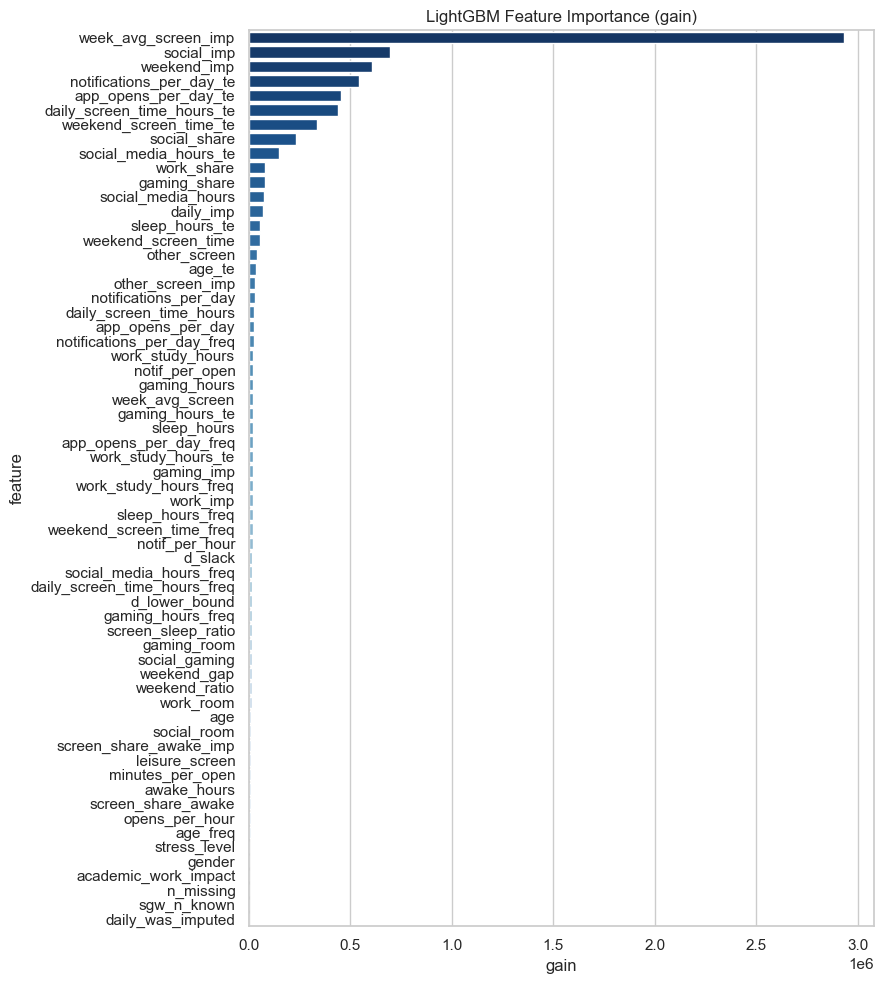

,feature,gain
0,week_avg_screen_imp,2.933407e+06
1,social_imp,6.983537e+05
2,weekend_imp,6.084701e+05
3,notifications_per_day_te,5.416426e+05
4,app_opens_per_day_te,4.557047e+05
...,...,...
57,gender,3.737721e+03
58,academic_work_impact,2.501149e+03
59,n_missing,2.167178e+03
60,sgw_n_known,1.350233e+02


In [25]:
# Feature importance (LightGBM, gain)
imp = pd.DataFrame({
    'feature': FEATURES,
    'gain': lgb_model.booster_.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=False)

fig, ax = plt.subplots(figsize=(9, 10))
sns.barplot(data=imp, y='feature', x='gain', palette='Blues_r', ax=ax)
ax.set_title('LightGBM Feature Importance (gain)')
plt.tight_layout(); plt.show()

display(imp.reset_index(drop=True))

In [26]:
# Submission
# A single file: whichever candidate the blend cell selected by OOF AUC (BEST).
# In round 1 the blend and the best single model were indistinguishable on the LB
# (0.96632 vs 0.96636, a 0.00004 gap = noise) with a Spearman correlation of 0.9993,
# so writing and uploading the individual model files just burns submission budget.
import os

os.makedirs('../submissions', exist_ok=True)

submission = pd.DataFrame({
    'id': test_df['id'].values,
    TARGET: blend_test,
})
submission.to_csv('../submissions/submission.csv', index=False)

print('selected candidate:', BEST)
print('written           : ../submissions/submission.csv', submission.shape)
if BEST.startswith(('rank', 'ridge')):
    # Ranks and Ridge outputs are monotone scores, not probabilities. AUC only reads the ordering,
    # so this is valid — it would be invalid under log loss.
    print(f'output is a ranking score, not a probability -> valid for AUC '
          f'(range {submission[TARGET].min():.4f} to {submission[TARGET].max():.4f})')
else:
    print('pred mean:', submission[TARGET].mean().round(4),
          '| train positive rate:', y.mean().round(4))

# To write out an individual model as well (test_preds is still in memory):
# pd.DataFrame({'id': test_df['id'].values, TARGET: test_preds['xgb']}) \
#   .to_csv('../submissions/submission_xgb.csv', index=False)

submission.head()

selected candidate: ridge_prob
written           : ../submissions/submission.csv (296302, 2)
output is a ranking score, not a probability -> valid for AUC (range 0.0009 to 0.9998)


,id,addicted_label
0,691369,0.999656
1,691370,0.959300
2,691371,0.819530
3,691372,0.994653
4,691373,0.998898


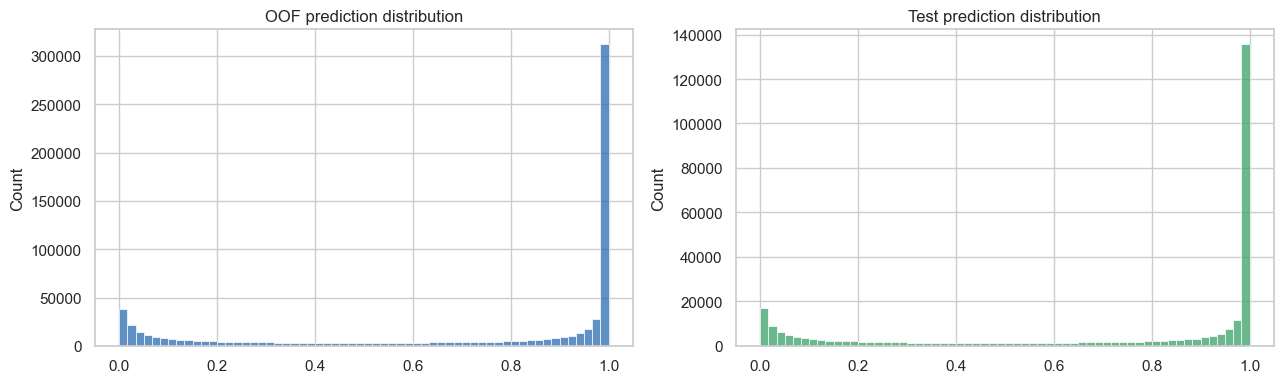

In [27]:
# Sanity check on the prediction distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(blend_oof, bins=60, ax=axes[0], color='#2b6cb0')
axes[0].set_title('OOF prediction distribution')
sns.histplot(blend_test, bins=60, ax=axes[1], color='#38a169')
axes[1].set_title('Test prediction distribution')
plt.tight_layout(); plt.show()

## 5. Results and Next Steps

### Leaderboard progress

| Round | Change | OOF AUC | LB |
|---|---|---|---|
| 1 | Baseline, 3000-iteration ceiling — XGBoost (5-fold) | 0.964864 | 0.96636 |
| 1 | Baseline blend, 0.69 xgb / 0.18 lgb / 0.13 cat | 0.964974 | 0.96632 |
| 2 | Raised iteration ceilings + rank blending option | — | 0.96647 |
| 3 | Constraint imputation + exact-value TE + 10-fold | 0.968456 | 0.96963 |
| 4 | `TE_SKIP` + pairwise TE, shipped together | — | 0.96743 |
| 5–6 | CV-only ablation rounds, no submissions | — | — |
| 7 | + frequency encoding | — | **0.96984** |
| 8 | context-conditional TE / jagged categoricals — all rejected on CV | — | not submitted |

Round 3 gained +0.00316, more than every other round combined. Round 4 gave back 0.0022 and was rolled
back. Rounds 5 and 6 spent no submissions at all.

**Round 7 is the payoff from fixing the method.** The paired ablation predicted +0.000224; the leaderboard
delivered +0.00021. The CV harness now predicts leaderboard movement in both direction and magnitude,
which is worth more than the 0.0002 itself — it means further ideas can be screened without spending
submissions.

### Target encoding is the whole story

The EDA labelled `notifications_per_day` (AUC 0.492) and `app_opens_per_day` (0.541) as chance-level
features. Exact-value target encoding showed how wrong that was — 0.4921 → 0.7485 and 0.5409 → 0.7349.
**Single-feature AUC measures monotonic separation, not information**; a zig-zag relationship scores 0.50
while being highly predictive, and the decile plot in section 2 had shown that pattern all along.

How extreme the jaggedness is, on `notifications_per_day`: the per-value target rate runs from 0.372 to
0.932 with ~2,200 rows behind each value, so the standard error per value is about 0.010. The label
depends on the exact integer the way it would on a lookup table, not on a numeric trend. Summing the
exact-value logit offsets of the four "worthless" columns (`age`, `notifications`, `app_opens`,
`sleep_hours`) and nothing else already gives AUC 0.830.

The section 3b ablations then measured everything else against it:

| Idea | Effect | Verdict |
|---|---|---|
| Target encoding on the smooth columns | −0.002532 to remove | essential |
| Frequency encoding | +0.000224, t = 4.95, 5/5 folds | adopted → LB +0.00021 |
| Sharper TE smoothing (`te5`) | +0.000064, t = 2.30, 4/5 | rejected |
| Two-granularity TE (`te1d`) | −0.000028 | nothing |
| Pairwise TE, binned — jagged × jagged | −0.000034 | nothing *(see below)* |
| Pairwise TE, exact — jagged × jagged | −0.000121 | nothing *(see below)* |
| Constraint-aware imputation | −0.000062 to remove | nothing measurable |
| Hand-built ratio features | −0.000047 to remove | nothing measurable |

Both winners came from the same insight: the data is synthetic, its generator reproduces values from a
source dataset, and both the exact value and its rate of occurrence are traces of that source.
Hand-built domain features contributed nothing on top of them.

### The interaction question, reopened and settled

Rounds 4 and 5 concluded that "pair encoding is closed — the two-column interaction genuinely carries
nothing extra here". That over-read the evidence. All three pairs tested crossed one *jagged* column with
another, which fails for reasons unrelated to whether interactions exist: 231 × 166 = 38k cells at ~18
rows each is not estimable, and both sides carry the same kind of signal anyway. **Jagged × smooth was
never tested.**

A direct diagnostic says there is something there. Split train at the median of `daily_screen_time_hours`
and compute each exact value's logit offset from its own group's base rate; a purely additive fingerprint
would reproduce the same offsets in both halves.

| column | values | corr(low, high) |
|---|---|---|
| `notifications_per_day` | 197 | **+0.878** |
| `app_opens_per_day` | 158 | **+0.882** |
| `age` | 18 | +0.857 |
| `sleep_hours` | 313 | +0.655 |

At ~1000 rows per cell the attenuation from sampling noise is at most ~1%, and correlation is
scale-invariant — so the per-value pattern genuinely changes with the rest of the row.

**Round 8 tested it, and nothing was adopted.**

| Variant | mean Δ | t | folds won | boot P(Δ>0) |
|---|---|---|---|---|
| `+ ctx8` | +0.000047 | 2.25 | 4/5 | 0.84 |
| `+ ctx4` | +0.000024 | 0.54 | 2/5 | 0.68 |
| `+ jagged cat` | **−0.001156** | −15.78 | 0/5 | 0.00 |

**The interaction is real in the data, but the model already has it.** A GBDT holding
`notifications_per_day_te` and `daily_screen_time_hours` as separate columns can split on one and then the
other, and *that is* the interaction term. An explicit conditional encoding only pays when the tree cannot
find that partition, and evidently it can. Verified structure in the data does not imply a gain from an
explicit feature for it.

**`+ jagged cat` failed on leakage, not capacity.** LightGBM fits its categorical split in-fold — at each
node it sorts categories by their gradient statistics and partitions the sorted set, which on a 231-level
column amounts to an in-fold target statistic. The TE columns already carry that information out-of-fold,
so the second, leaky route to the same signal costs 0.0012. That is indirect confirmation that the OOF
discipline around the encodings is doing real work. It condemns LightGBM's mechanism, not CatBoost's
ordered target statistics — but that variant cannot be screened in this harness and is not worth a
multi-hour run, since CatBoost is the weakest of the three and adds almost nothing to the blend.

**And the harness has reached its resolution limit.** `ctx8`'s fold SE is 0.000021, its bootstrap SE
~0.00004; the effect sits at the edge of both instruments, which is why they disagree. Ten folds would
shrink the fold SE by only √2 for 80 minutes. An effect this size cannot be established at any affordable
cost — which settles it rather than leaving it open.

**The encoding axis is closed for real now**, not by assumption but by having tested the family rounds 4
and 5 skipped.

### Directions checked and ruled out

These follow naturally from the generator-fingerprint theme and are all dead ends here. Recorded so they
do not get re-tried:

- **Decimal-precision fingerprint.** Generators sometimes leak the source through how many decimals a
  value carries. Not here: every float column is ~90% two-decimal / ~9% one-decimal with no target
  relationship (AUC of the decimal count runs 0.496–0.507 across all nine columns), and the three
  integer columns are integers throughout.
- **Row-level duplicates / near-duplicate group size.** 987,671 train+test rows produce 987,654 distinct
  9-column combinations. There is no duplicate structure to count, and AUC of the group size is 0.5000.
- **Encoding coverage gaps.** Fewer than 0.01% of test rows carry an exact value never seen in train, in
  every column. There are no thin regions for the encoding tables — which removes the main rationale for
  original-dataset augmentation.

### Two method errors, and what they cost

**Round 4 shipped two changes in one submission** and lost 0.0022 with no way to attribute it. The
ablation later showed `TE_SKIP` caused all of it and the pairs none. The justification for `TE_SKIP` had
been that those encodings scored below their raw columns as standalone predictors — never evidence that a
model holding both is better off without one. The raw column carries the smooth trend; the encoding
carries each exact value's deviation from it.

**The first ablation threshold was too strict.** It compared each variant's mean AUC against the largest
fold-to-fold standard deviation. But every variant sees the same folds, so fold difficulty cancels in a
between-variant comparison; using it as noise buried real effects. Switching to a paired per-fold test
turned frequency encoding from "+0.000219, below the bar" into "t = 4.95, 5/5 folds" — same data,
correctly read — and the leaderboard then confirmed it. Rounds 5 and 6 were spent because of that mistake.

A third one is worth naming, caught before it cost a round: **a negative result is only as broad as the
variant that produced it.** "Pairs measured at zero" became "pair encoding is closed" without anyone
checking that the pairs tested covered the idea. Round 8 tested the missing family and reached the same
conclusion — which is the only way that conclusion was ever going to be worth relying on.

**Generalisable takeaways:**
- On synthetic tabular data, test whether numerical columns behave like high-cardinality categoricals
  before treating them as continuous. Read the binned response curve, not the correlation.
- Compare model variants with a paired test on shared folds. Between-fold variance is not between-variant
  noise, and treating it as such hides effects that are actually real.
- Keep the ablation baseline pinned to the configuration you actually submit.
- One change per submission, and prove it on CV first.
- Structure verified in the data is not the same as a gain from a feature encoding it. Trees build
  interactions natively; an explicit interaction feature only pays where they cannot.
- Know the instrument's resolution. Once an effect sits at the edge of both the fold test and the row
  bootstrap, "run it again with more folds" does not rescue it — that is the signal to stop, not to
  measure harder.

### Where this stands

**Feature engineering is done.** Every hand-built domain feature measured at zero, and round 8 closed the
last open encoding family by testing it rather than assuming it. The ceiling, however, is less certain
than it looked. A LightGBM
trained only on complete rows scores ~0.9698, roughly where the full pipeline sits, and that was read as a
ceiling. It is not one: complete rows are **44.3%** of train (306k of 691k), so that model is missing over
half its data. It is a rough sanity read, not a bound in either direction.

Ranked by expected value:

1. **Diversity for the blend.** OOF correlations sit at 0.996–0.998, which is why every blend has beaten
   the best single model by ≤0.0002. `RUN_LGB_ET` is the same algorithm on the same features and may not
   move that. The sharper split is by **feature set**: one model on raw + engineered with no encodings,
   one on encodings only. Those two model different things by construction, so their errors should
   actually differ — which is what the meta-learner needs to have anything to cancel.
2. **Meta-learner blending** (`ridge_prob`, `ridge_rank`, `logit_prob`) — already staged in the blend
   cell, and only worth its keep once (1) has lowered the correlations.
3. **Targeted hyperparameter search before a full Optuna run.** The TE columns are jagged, so
   `num_leaves = 64` with `min_child_samples = 60` may be clipping their resolution. Sweep
   `num_leaves ∈ {64, 128, 256}` × `min_child_samples ∈ {20, 60, 150}` at 3 folds first; open Optuna only
   if that axis shows signal.
4. **Multi-seed bagging** — mechanical, reliable, roughly +0.0002, costs runtime linearly.
5. **Nested target encoding** — removes the last structural doubt about OOF. Low priority: CV and LB have
   agreed at every round (+0.00117 offset at round 3, and round 7 landed within 0.00002 of prediction).
6. **Original dataset augmentation** — demoted. The usual rationale is extra support for the encoding
   tables in thin regions, and the coverage check above found no thin regions.
